### 7. Modelado final para la estimación de la Probabilidad de Default

#### 7.1 Objetivo

El objetivo de este notebook es comparar el rendimiento de distintos modelos de Machine Learning entrenados con datos reales y con el conjunto sintético seleccionado, Gaussian Copula V2.1, para la estimación de la Probabilidad de Default.

A diferencia de los notebooks anteriores, donde LightGBM fue utilizado principalmente como modelo diagnóstico común para evaluar la utilidad predictiva de los sintetizadores, en esta etapa se realiza el modelado predictivo definitivo del estudio.

Se evaluarán los siguientes algoritmos:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM

Cada modelo será entrenado bajo dos escenarios:

- **Real:** entrenamiento con datos reales.
- **Synthetic:** entrenamiento con datos sintéticos Gaussian Copula V2.1.

La evaluación se realizará sobre un mismo conjunto de prueba compuesto exclusivamente por observaciones reales, con el objetivo de medir de forma comparable la capacidad de generalización de cada modelo.

Las métricas principales serán ROC-AUC y PR-AUC, complementadas con Precision, Recall, F1-Score y matrices de confusión.

Posteriormente, a partir de los resultados obtenidos, se seleccionará el modelo predictivo más adecuado para la etapa de explicabilidad mediante SHAP.

#### 7.2 Configuración experimental

##### 7.2.1 Diseño de comparación

Dataset real preparado
        │
        ├── 80% Train Real ────────> Modelo Real ──┐
        │                                          │
        └── 20% Test Real  <───────────────────────┤
                                                   │
Gaussian Copula V2.1                               │
        │                                          │
        └── Train Synthetic ──> Modelo Synthetic ──┘


Escenario Real
Train Real → Test Real
Escenario Synthetic
Train Synthetic → Test Real

Esto es esencialmente TRTR y TSTR, pero ahora aplicado a cada algoritmo de Machine Learning, no únicamente al LightGBM diagnóstico.

¿Usaremos todo Gaussian V2.1 para entrenar?

Sí.

Tenemos aproximadamente:

real completo: 307,507
synthetic completo: 307,507
real test: aproximadamente 61,502
real train: aproximadamente 246,005

Aquí hay dos opciones metodológicas:

Opción A: entrenar el modelo sintético con los 307,507 registros sintéticos.

Opción B: utilizar solo 246,005 registros sintéticos para igualar exactamente el tamaño del train real.

Para la comparación principal, yo recomiendo Opción B.

¿Por qué?

Porque así controlamos otra variable experimental:

ambos modelos reciben aproximadamente la misma cantidad de observaciones de entrenamiento.

Si Real recibe 246k y Synthetic recibe 307k, una diferencia de rendimiento podría estar influenciada parcialmente por la cantidad de datos.

Por tanto, para Notebook 07:

Train Real = 80% de datos reales
Train Synthetic = mismo número de filas que Train Real
Test = mismo 20% de datos reales

Y siempre con random_state=42.

Esto hace la comparación más limpia que la que usamos para selección de sintetizadores, donde nuestro propósito era distinto.

##### 7.2.2 Variables del modelo

Seguimos excluyendo:

TARGET
SK_ID_CURR

SK_ID_CURR es un identificador, por lo que no debe participar como predictor.

Las demás variables quedan disponibles.

In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
#Leer desde drive
from google.colab import drive
drive.mount('/content/drive')

pd.set_option("display.max_columns", None)

ruta = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/02_Data_Preparation/dataset_real_final.parquet"

df_real = pd.read_parquet(ruta)

print("Dataset real:", df_real.shape)

print("\nTARGET REAL:")
print(df_real["TARGET"].value_counts(normalize=True))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset real: (307507, 41)

TARGET REAL:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


In [ ]:
TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

features_modelo = [
    col for col in df_real.columns
    if col not in [TARGET_COL, ID_COL]
]

print("Número de variables predictoras:", len(features_modelo))
print(features_modelo)

Número de variables predictoras: 39
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']


##### 7.2.3 División real Train/Test

In [ ]:
from sklearn.model_selection import train_test_split

X_real = df_real[features_modelo].copy()
y_real = df_real[TARGET_COL].copy()

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.20,
    stratify=y_real,
    random_state=42
)

print("Train real:", X_train_real.shape)
print("Test real :", X_test_real.shape)

print("\nDistribución TARGET - Train real")
print(y_train_real.value_counts(normalize=True).sort_index())

print("\nDistribución TARGET - Test real")
print(y_test_real.value_counts(normalize=True).sort_index())

Train real: (246005, 39)
Test real : (61502, 39)

Distribución TARGET - Train real
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

Distribución TARGET - Test real
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


##### 7.2.4 Construcción del Train Synthetic comparable

Tomamos exactamente el mismo número de observaciones que X_train_real.

Como Gaussian V2.1 ya tiene TARGET controlado, haremos un muestreo estratificado para conservar también la prevalencia.

In [ ]:
df_gc_v21 = pd.read_parquet("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM//05_Synthetic_Data_Optimization/df_synth_v21.parquet")

print("Gaussian Copula V2.1:", df_gc_v21.shape)

print("\nTARGET GC V2.1:")
print(df_gc_v21["TARGET"].value_counts(normalize=True))

Gaussian Copula V2.1: (307507, 41)

TARGET GC V2.1:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


In [ ]:
df_synthetic_model = df_gc_v21[
    features_modelo + [TARGET_COL]
].copy()

X_synthetic = df_synthetic_model[features_modelo]
y_synthetic = df_synthetic_model[TARGET_COL]

X_train_synth, _, y_train_synth, _ = train_test_split(
    X_synthetic,
    y_synthetic,
    train_size=len(X_train_real),
    stratify=y_synthetic,
    random_state=42
)

print("Train synthetic:", X_train_synth.shape)

print("\nDistribución TARGET - Train synthetic")
print(y_train_synth.value_counts(normalize=True).sort_index())

Train synthetic: (246005, 39)

Distribución TARGET - Train synthetic
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


Así quedan controlados:

número de registros;
proporción de TARGET;
número de variables;
test real;
métricas;
algoritmo.

Lo único que cambia es:

fuente de los datos de entrenamiento: Real vs Synthetic.

Ese diseño es muy bueno para tu Objetivo 4.

##### 7.2.5 Una cuestión muy importante: el preprocesamiento

Aquí no conviene usar un encoder único aprendido con todo el dataset.

Para cada escenario:

Modelo Real

El preprocesador se ajusta exclusivamente con:

X_train_real

y transforma:

X_train_real
X_test_real
Modelo Synthetic

El preprocesador se ajusta exclusivamente con:

X_train_synth

y transforma:

X_train_synth
X_test_real

Esto evita fuga de información desde el test real.

Y además refleja el caso real de uso:

si solamente dispusiéramos de datos sintéticos para desarrollar el modelo, el pipeline de entrenamiento también tendría que aprender su preprocesamiento desde los sintéticos.

##### 7.2.6 Métricas

Métricas de evaluación

Dado el desbalance de la variable objetivo, la evaluación considera
ROC-AUC y PR-AUC como métricas principales. Adicionalmente, se calculan
Precision, Recall y F1-Score utilizando inicialmente un umbral de
clasificación de 0.50.

El mismo umbral se mantiene para todos los modelos con el objetivo de
garantizar condiciones de comparación homogéneas.

##### 7.2.7 Función común de evaluación

In [ ]:
#Vamos a crear una función que utilizaremos para todos los modelos:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluar_modelo(
    nombre_modelo,
    fuente_entrenamiento,
    modelo,
    X_test,
    y_test,
    threshold=0.50
):

    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    resultados = {
        "Modelo": nombre_modelo,
        "Entrenamiento": fuente_entrenamiento,
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        )
    }

    matriz = confusion_matrix(y_test, y_pred)

    return resultados, matriz

##### 7.2.8 Verificación del diseño experimental

La configuración experimental final utiliza 39 variables predictoras, excluyendo TARGET y SK_ID_CURR.

El conjunto real fue dividido mediante muestreo estratificado en:

- 246 005 observaciones para entrenamiento.
- 61 502 observaciones para evaluación.

El conjunto sintético Gaussian Copula V2.1 fue muestreado hasta obtener igualmente 246 005 observaciones de entrenamiento.

La prevalencia de la clase positiva se mantiene prácticamente idéntica en los conjuntos de entrenamiento real, entrenamiento sintético y prueba real, con aproximadamente un 8.073 % de observaciones correspondientes a TARGET = 1.

De esta forma, los escenarios Real y Synthetic utilizan el mismo número de observaciones, las mismas variables predictoras y el mismo conjunto real de evaluación. Esto permite que las diferencias de rendimiento observadas se atribuyan principalmente a la fuente de los datos utilizados durante el entrenamiento.

Una precisión: yo usaría “principalmente” y no “exclusivamente”, porque pueden existir diferencias derivadas del preprocesamiento aprendido en cada fuente.

#### 7.3 Modelado Real vs Synthetic - Antes de Logistic Regression: preprocesamiento

Tenemos variables numéricas y categóricas. Para esta notebook es mejor construir un ColumnTransformer.

Además, hay una diferencia importante:

Logistic Regression sí se beneficia claramente del escalado numérico.
RF, XGBoost y LightGBM no lo necesitan.

Para mantener una implementación clara, usaremos dos preprocessors:

preprocessor_lr: OneHot + StandardScaler.
preprocessor_tree: OneHot + numéricas sin escalar.

Primero identifiquemos tipos usando el train real como referencia de estructura, no para aprender categorías ni parámetros.

In [ ]:
categorical_cols = (
    X_train_real
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numerical_cols = [
    col for col in features_modelo
    if col not in categorical_cols
]

print("Variables categóricas:", len(categorical_cols))
print(categorical_cols)

print("\nVariables numéricas:", len(numerical_cols))
print(numerical_cols)

Variables categóricas: 12
['CODE_GENDER', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START']

Variables numéricas: 27
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'OWN_CAR_AGE', 'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']


##### 7.3.1 Preprocesador para Logistic Regression

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr_real = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

preprocessor_lr_synth = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

¿Por qué dos objetos aunque sean idénticos en definición?

Porque debemos hacer:

preprocessor REAL → fit exclusivamente sobre Train Real


preprocessor SYNTH → fit exclusivamente sobre Train Synthetic

No queremos reutilizar el encoder/scaler aprendido con reales para el modelo sintético.

###### 7.3.1.1 Transformación independiente

In [ ]:
X_train_real_lr = preprocessor_lr_real.fit_transform(
    X_train_real
)

X_test_real_lr = preprocessor_lr_real.transform(
    X_test_real
)

X_train_synth_lr = preprocessor_lr_synth.fit_transform(
    X_train_synth
)

X_test_real_from_synth_lr = preprocessor_lr_synth.transform(
    X_test_real
)

print("Escenario Real")
print("Train:", X_train_real_lr.shape)
print("Test :", X_test_real_lr.shape)

print("\nEscenario Synthetic")
print("Train:", X_train_synth_lr.shape)
print("Test :", X_test_real_from_synth_lr.shape)

Escenario Real
Train: (246005, 150)
Test : (61502, 150)

Escenario Synthetic
Train: (246005, 150)
Test : (61502, 150)


###### 7.3.1.2 Primer modelo definitivo: Logistic Regression

Para empezar, no haremos tuning. Primero establecemos el rendimiento base bajo exactamente la misma configuración.

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr_real = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo_lr_synth = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [ ]:
#Entrenamos
modelo_lr_real.fit(
    X_train_real_lr,
    y_train_real
)

modelo_lr_synth.fit(
    X_train_synth_lr,
    y_train_synth
)

LogisticRegression(max_iter=2000, random_state=42)

###### 7.3.1.3 Evaluación Real vs Synthetic

In [ ]:
resultado_lr_real, cm_lr_real = evaluar_modelo(
    nombre_modelo="Logistic Regression",
    fuente_entrenamiento="Real",
    modelo=modelo_lr_real,
    X_test=X_test_real_lr,
    y_test=y_test_real
)

resultado_lr_synth, cm_lr_synth = evaluar_modelo(
    nombre_modelo="Logistic Regression",
    fuente_entrenamiento="Synthetic",
    modelo=modelo_lr_synth,
    X_test=X_test_real_from_synth_lr,
    y_test=y_test_real
)

tabla_lr = pd.DataFrame([
    resultado_lr_real,
    resultado_lr_synth
])

tabla_lr.round(6)

,Modelo,Entrenamiento,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Logistic Regression,Real,0.744036,0.224755,0.530435,0.012286,0.024016
1,Logistic Regression,Synthetic,0.734700,0.217511,0.000000,0.000000,0.000000


In [ ]:
print("Matriz de confusión - Logistic Regression REAL")
print(cm_lr_real)

print("\nMatriz de confusión - Logistic Regression SYNTHETIC")
print(cm_lr_synth)

Matriz de confusión - Logistic Regression REAL
[[56483    54]
 [ 4904    61]]

Matriz de confusión - Logistic Regression SYNTHETIC
[[56536     1]
 [ 4965     0]]


Consideración sobre el umbral de clasificación

Debido a la baja prevalencia de la clase positiva, Precision, Recall y
F1-Score pueden presentar valores reducidos utilizando un umbral de 0.50.

Por este motivo, ROC-AUC y PR-AUC resultan especialmente relevantes para
la comparación inicial de los modelos. El umbral se mantiene constante
en esta etapa para preservar la comparabilidad entre experimentos.

1. Logistic Regression: Real vs Synthetic


| Entrenamiento         |      ROC-AUC |       PR-AUC | Precision |   Recall |       F1 |
| --------------------- | -----------: | -----------: | --------: | -------: | -------: |
| **Real**              | **0.744036** | **0.224755** |  0.530435 | 0.012286 | 0.024016 |
| **Synthetic GC V2.1** |     0.734700 |     0.217511 |  0.000000 | 0.000000 | 0.000000 |


Lo primero que destacaría es que, en las métricas independientes del umbral, la pérdida es pequeña.

Para ROC-AUC:

0.744036 → 0.734700

Diferencia absoluta:

0.009336

El modelo sintético conserva aproximadamente el 98.75% del ROC-AUC del mismo algoritmo entrenado con datos reales.

En PR-AUC:

0.224755 → 0.217511

Diferencia:

0.007244

equivalente aproximadamente al 96.78% del PR-AUC real.

Esto es un resultado bastante bueno para la pregunta principal de tu TFM.

2. Entonces, ¿por qué Precision, Recall y F1 son cero?

Por el threshold = 0.50.

La matriz sintética es:

[[56536     1]
 [ 4965     0]]

El modelo clasificó solamente una observación como positiva, y era realmente negativa.

Pero esto no significa que Logistic Regression sintética no haya aprendido a discriminar defaults.

Su:

ROC-AUC = 0.734700

y:

PR-AUC = 0.217511

demuestran que las probabilidades generadas sí contienen capacidad para ordenar los casos de mayor y menor riesgo.

Lo que ocurre es que prácticamente ninguna probabilidad supera 0.50.

Este es justamente el motivo por el que separar métricas dependientes e independientes del threshold es importante.


El modelo real tampoco funciona bien operacionalmente con 0.50:

61 TP
4,904 FN
Recall = 1.23%

Es decir, incluso entrenando con datos reales, el umbral estándar deja escapar casi todos los defaults.

Por tanto, no es un problema exclusivo del dataset sintético; es especialmente visible allí.

3. Esto nos sugiere algo para más adelante

No cambiaremos el threshold ahora.

Primero debemos comparar LR, RF, XGBoost y LightGBM todos bajo el mismo protocolo.

Después, cuando seleccionemos el modelo final, podremos determinar un threshold usando únicamente datos de entrenamiento/validación, nunca mirando el test real para escoger el umbral.

Eso será importante porque nuestro dataset tiene solamente ~8% de positivos.

###### 7.3.1.4 Interpretación de Logistic Regression

Logistic Regression entrenada con datos reales obtuvo un ROC-AUC de 0.744036 y un PR-AUC de 0.224755. El modelo entrenado con Gaussian Copula V2.1 alcanzó un ROC-AUC de 0.734700 y un PR-AUC de 0.217511.

La diferencia de ROC-AUC entre ambos escenarios fue de 0.009336, mientras que la diferencia de PR-AUC fue de 0.007244. El modelo entrenado con datos sintéticos alcanzó aproximadamente el 98.75 % del ROC-AUC y el 96.78 % del PR-AUC obtenidos por el mismo algoritmo entrenado con datos reales.

Estos resultados indican que, para Logistic Regression, los datos sintéticos preservan una parte elevada de la capacidad discriminativa observada al utilizar datos reales.

Sin embargo, utilizando un umbral de clasificación de 0.50, ambos modelos presentan una capacidad muy limitada para identificar la clase positiva. El modelo real alcanza un Recall de 0.012286, mientras que el modelo sintético no identifica correctamente ningún caso positivo.

En el escenario sintético, este comportamiento no implica ausencia de capacidad discriminativa, dado que el ROC-AUC de 0.734700 y el PR-AUC de 0.217511 muestran que las probabilidades estimadas permiten diferenciar parcialmente entre observaciones de mayor y menor riesgo. La discrepancia se encuentra asociada al comportamiento de las probabilidades respecto al umbral de decisión utilizado.

Por este motivo, ROC-AUC y PR-AUC se utilizan como métricas principales para la comparación inicial de modelos, mientras que Precision, Recall y F1-Score se interpretan conjuntamente con el umbral de clasificación. La posible optimización del umbral será evaluada posteriormente sobre el modelo seleccionado y sin utilizar el conjunto real de prueba para su ajuste.

4. Antes de Random Forest: una mejora metodológica

Para los árboles no escalaremos las variables numéricas.

Creamos los preprocessors:

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_tree_real = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

preprocessor_tree_synth = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [ ]:
#Transformamos independientemente
X_train_real_tree = preprocessor_tree_real.fit_transform(
    X_train_real
)

X_test_real_tree = preprocessor_tree_real.transform(
    X_test_real
)

X_train_synth_tree = preprocessor_tree_synth.fit_transform(
    X_train_synth
)

X_test_real_from_synth_tree = preprocessor_tree_synth.transform(
    X_test_real
)

print("Escenario Real")
print("Train:", X_train_real_tree.shape)
print("Test :", X_test_real_tree.shape)

print("\nEscenario Synthetic")
print("Train:", X_train_synth_tree.shape)
print("Test :", X_test_real_from_synth_tree.shape)

Escenario Real
Train: (246005, 150)
Test : (61502, 150)

Escenario Synthetic
Train: (246005, 150)
Test : (61502, 150)


##### 7.3.2 Random Forest

In [ ]:
#Para la primera comparación no hagamos tuning todavía.
from sklearn.ensemble import RandomForestClassifier

modelo_rf_real = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_rf_synth = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [ ]:
#Entrenmaiento
modelo_rf_real.fit(
    X_train_real_tree,
    y_train_real
)

modelo_rf_synth.fit(
    X_train_synth_tree,
    y_train_synth
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
#Evaluacion:
resultado_rf_real, cm_rf_real = evaluar_modelo(
    nombre_modelo="Random Forest",
    fuente_entrenamiento="Real",
    modelo=modelo_rf_real,
    X_test=X_test_real_tree,
    y_test=y_test_real
)

resultado_rf_synth, cm_rf_synth = evaluar_modelo(
    nombre_modelo="Random Forest",
    fuente_entrenamiento="Synthetic",
    modelo=modelo_rf_synth,
    X_test=X_test_real_from_synth_tree,
    y_test=y_test_real
)

tabla_rf = pd.DataFrame([
    resultado_rf_real,
    resultado_rf_synth
])

tabla_rf.round(6)

,Modelo,Entrenamiento,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Random Forest,Real,0.733735,0.226612,0.785714,0.002216,0.004419
1,Random Forest,Synthetic,0.656235,0.151885,0.000000,0.000000,0.000000


In [ ]:
print("Matriz de confusión - Random Forest REAL")
print(cm_rf_real)

print("\nMatriz de confusión - Random Forest SYNTHETIC")
print(cm_rf_synth)

Matriz de confusión - Random Forest REAL
[[56534     3]
 [ 4954    11]]

Matriz de confusión - Random Forest SYNTHETIC
[[56537     0]
 [ 4965     0]]


1. Random Forest: Real vs Synthetic


| Entrenamiento |      ROC-AUC |       PR-AUC | Precision |   Recall |       F1 |
| ------------- | -----------: | -----------: | --------: | -------: | -------: |
| **Real**      | **0.733735** | **0.226612** |  0.785714 | 0.002216 | 0.004419 |
| **Synthetic** |     0.656235 |     0.151885 |         0 |        0 |        0 |




La caída Real → Synthetic es ahora considerablemente mayor.

Para ROC-AUC:

0.733735 → 0.656235

Diferencia absoluta:

0.077500

El modelo sintético alcanza aproximadamente el 89.44% del ROC-AUC del modelo real.

En PR-AUC:

0.226612 → 0.151885

Diferencia:

0.074727

equivalente aproximadamente al 67.02% del PR-AUC real.

Esto contrasta bastante con Logistic Regression.


| Modelo              | ROC-AUC Real | ROC-AUC Synthetic |          Gap | Synthetic/Real |
| ------------------- | -----------: | ----------------: | -----------: | -------------: |
| Logistic Regression |     0.744036 |          0.734700 | **0.009336** |     **98.75%** |
| Random Forest       |     0.733735 |          0.656235 | **0.077500** |     **89.44%** |




Esto ya nos está mostrando que no deberíamos hablar de “la utilidad predictiva del dataset sintético” como si fuera un único número universal. La utilidad observada depende del modelo utilizado.

2. La matriz sintética tampoco es un error

Random Forest Synthetic:

[[56537     0]
 [ 4965     0]]

Predijo literalmente todos los registros como clase 0 con threshold 0.50.

Pero nuevamente:

ROC-AUC = 0.656235 > 0.50

y:

PR-AUC = 0.151885 > prevalencia positiva ≈ 0.0807

Así que existe capacidad de ranking, aunque bastante más débil que con datos reales.

El problema de Precision = Recall = F1 = 0 bajo 0.50 es diferente de afirmar que el modelo no aprendió nada.

3. Incluso Random Forest Real casi nunca predice default

Su matriz:

[[56534     3]
 [ 4954    11]]

De los 4,965 defaults reales, identifica solamente 11.

Por eso:

Recall = 0.002216 = 0.22%

La Precision de 0.785714 parece espectacular aislada, pero debe interpretarse con mucho cuidado: el modelo predijo positivo solo 14 veces y acertó 11.

Este es un ejemplo perfecto de por qué Precision aislada puede ser engañosa en problemas fuertemente desbalanceados.

**Resultados de Random Forest**

Random Forest entrenado con datos reales obtuvo un ROC-AUC de 0.733735 y un PR-AUC de 0.226612. Al utilizar Gaussian Copula V2.1 como fuente de entrenamiento, estas métricas disminuyeron hasta 0.656235 y 0.151885, respectivamente.

La diferencia absoluta de ROC-AUC entre ambos escenarios fue de 0.077500, considerablemente superior a la observada previamente mediante Logistic Regression. El modelo Random Forest entrenado con datos sintéticos alcanzó aproximadamente el 89.44 % del ROC-AUC obtenido por el mismo algoritmo entrenado con datos reales.

En PR-AUC, el modelo sintético alcanzó aproximadamente el 67.02 % del resultado obtenido mediante entrenamiento real, evidenciando una pérdida más pronunciada en la capacidad de priorizar correctamente la clase minoritaria.

Utilizando un umbral de clasificación de 0.50, el modelo entrenado con datos sintéticos clasificó todas las observaciones como no-default, obteniendo Precision, Recall y F1-Score iguales a cero. Sin embargo, el ROC-AUC superior a 0.50 y el PR-AUC superior a la prevalencia de la clase positiva indican que el modelo mantiene cierta capacidad discriminativa en las probabilidades generadas, aunque insuficiente para producir clasificaciones positivas bajo el umbral utilizado.

El modelo entrenado con datos reales también presenta un Recall muy reducido bajo el umbral de 0.50, identificando únicamente 11 de los 4 965 casos positivos del conjunto de prueba. Por este motivo, la elevada Precision observada debe interpretarse conjuntamente con el reducido número de predicciones positivas.

Al comparar estos resultados con Logistic Regression, se observa que la pérdida de rendimiento asociada al entrenamiento sintético no es uniforme entre algoritmos. Logistic Regression presentó una reducción de ROC-AUC de únicamente 0.009336, mientras que Random Forest presentó una reducción de 0.077500. Este resultado sugiere que la utilidad predictiva del conjunto sintético puede depender de la familia de modelo utilizada, aspecto que será contrastado posteriormente mediante XGBoost y LightGBM.

##### 7.3.3 XGboost

5. Pasamos a XGBoost

Aquí reutilizamos:

X_train_real_tree
X_test_real_tree

X_train_synth_tree
X_test_real_from_synth_tree

No necesitamos volver a transformar nada.

Para mantener inicialmente una configuración comparable y evitar tuning prematuro:

In [ ]:
from xgboost import XGBClassifier

modelo_xgb_real = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

modelo_xgb_synth = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

Aquí hay una decisión importante: por ahora no pondremos scale_pos_weight.

Queremos observar primero el comportamiento natural bajo el mismo desbalance de aproximadamente 8.07%. El tratamiento del desbalance formará parte, si es necesario, de la optimización posterior.

In [ ]:
modelo_xgb_real.fit(
    X_train_real_tree,
    y_train_real
)

modelo_xgb_synth.fit(
    X_train_synth_tree,
    y_train_synth
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
#Evaluamos
resultado_xgb_real, cm_xgb_real = evaluar_modelo(
    nombre_modelo="XGBoost",
    fuente_entrenamiento="Real",
    modelo=modelo_xgb_real,
    X_test=X_test_real_tree,
    y_test=y_test_real
)

resultado_xgb_synth, cm_xgb_synth = evaluar_modelo(
    nombre_modelo="XGBoost",
    fuente_entrenamiento="Synthetic",
    modelo=modelo_xgb_synth,
    X_test=X_test_real_from_synth_tree,
    y_test=y_test_real
)

tabla_xgb = pd.DataFrame([
    resultado_xgb_real,
    resultado_xgb_synth
])

tabla_xgb.round(6)

,Modelo,Entrenamiento,ROC_AUC,PR_AUC,Precision,Recall,F1
0,XGBoost,Real,0.763883,0.251195,0.581699,0.017925,0.034779
1,XGBoost,Synthetic,0.723400,0.200403,1.000000,0.000403,0.000805


In [ ]:
#MAtrices:
print("Matriz de confusión - XGBoost REAL")
print(cm_xgb_real)

print("\nMatriz de confusión - XGBoost SYNTHETIC")
print(cm_xgb_synth)

Matriz de confusión - XGBoost REAL
[[56473    64]
 [ 4876    89]]

Matriz de confusión - XGBoost SYNTHETIC
[[56537     0]
 [ 4963     2]]


Los resultados obtenidos fueron:


| Entrenamiento |      ROC-AUC |       PR-AUC | Precision |   Recall |       F1 |
| ------------- | -----------: | -----------: | --------: | -------: | -------: |
| **Real**      | **0.763883** | **0.251195** |  0.581699 | 0.017925 | 0.034779 |
| **Synthetic** |     0.723400 |     0.200403 |  1.000000 | 0.000403 | 0.000805 |



Las diferencias Real → Synthetic son:

ROC-AUC: 0.040483
PR-AUC: 0.050792
ROC-AUC relativo: aproximadamente 94.70%
PR-AUC relativo: aproximadamente 79.78%

XGBoost queda, por ahora, en una posición intermedia en cuanto a transferencia sintética:


| Modelo              | ROC-AUC Real | ROC-AUC Synthetic |          Gap |
| ------------------- | -----------: | ----------------: | -----------: |
| Logistic Regression |     0.744036 |          0.734700 | **0.009336** |
| Random Forest       |     0.733735 |          0.656235 | **0.077500** |
| XGBoost             | **0.763883** |      **0.723400** | **0.040483** |



Hay dos perspectivas diferentes: Logistic Regression conserva mejor su rendimiento relativo, pero XGBoost Real presenta hasta ahora la mayor capacidad discriminativa absoluta. Además, XGBoost Synthetic (0.7234) sigue manteniendo una capacidad discriminativa relevante sobre observaciones reales.

###### 7.3.3.1 Interpretación de resultados

XGBoost entrenado con datos reales obtuvo un ROC-AUC de 0.763883 y un PR-AUC de 0.251195, constituyendo hasta este punto el modelo con mayor capacidad discriminativa entre los algoritmos evaluados.

Al utilizar Gaussian Copula V2.1 como fuente de entrenamiento, XGBoost alcanzó un ROC-AUC de 0.723400 y un PR-AUC de 0.200403. La reducción absoluta respecto al entrenamiento real fue de 0.040483 en ROC-AUC y 0.050792 en PR-AUC. En términos relativos, el modelo sintético alcanzó aproximadamente el 94.70 % del ROC-AUC y el 79.78 % del PR-AUC obtenidos mediante entrenamiento real.

Estos resultados muestran una pérdida de utilidad predictiva superior a la observada mediante Logistic Regression, pero considerablemente inferior a la registrada mediante Random Forest. Por tanto, los resultados obtenidos hasta este punto respaldan la existencia de diferencias entre algoritmos en su capacidad para aprovechar las relaciones preservadas por el conjunto sintético.

Con un umbral de clasificación de 0.50, el modelo entrenado con datos reales identificó correctamente 89 de los 4 965 casos de default, obteniendo un Recall de 0.017925. El modelo entrenado con datos sintéticos identificó únicamente 2 casos positivos. Aunque estos dos casos fueron clasificados correctamente y la Precision resultante fue 1.0, este valor no debe interpretarse aisladamente como un elevado rendimiento de clasificación, dado que el Recall fue únicamente 0.000403.

La diferencia entre las métricas basadas en probabilidades y las métricas dependientes del umbral refuerza la necesidad de utilizar ROC-AUC y PR-AUC como criterios principales durante la comparación inicial. La adecuación del umbral de decisión será analizada posteriormente para el modelo seleccionado, evitando su optimización sobre el conjunto real de prueba.

NOTA: Ese último punto es importante: Precision = 1.0 no significa que XGBoost Synthetic sea perfecto. Predijo únicamente dos positivos y acertó ambos.

##### 7.3.4 LightGBM

Llegamos ahora al cuarto y último algoritmo del benchmark final.

Aquí hay una ventaja metodológica: ya conocemos LightGBM por los notebooks 05 y 06, pero no debemos reutilizar aquel 0.765600 como resultado final.

Ahora LightGBM se someterá al mismo protocolo exacto que LR, RF y XGBoost.

In [ ]:
#USaremos la configuracion base
from lightgbm import LGBMClassifier

modelo_lgbm_real = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

modelo_lgbm_synth = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [ ]:
#Entrenamiento
modelo_lgbm_real.fit(
    X_train_real_tree,
    y_train_real
)

modelo_lgbm_synth.fit(
    X_train_synth_tree,
    y_train_synth
)

LGBMClassifier(learning_rate=0.05, n_estimators=200, n_jobs=-1, random_state=42,
               verbosity=-1)

In [ ]:
#Evaluacion
resultado_lgbm_real, cm_lgbm_real = evaluar_modelo(
    nombre_modelo="LightGBM",
    fuente_entrenamiento="Real",
    modelo=modelo_lgbm_real,
    X_test=X_test_real_tree,
    y_test=y_test_real
)

resultado_lgbm_synth, cm_lgbm_synth = evaluar_modelo(
    nombre_modelo="LightGBM",
    fuente_entrenamiento="Synthetic",
    modelo=modelo_lgbm_synth,
    X_test=X_test_real_from_synth_tree,
    y_test=y_test_real
)

tabla_lgbm = pd.DataFrame([
    resultado_lgbm_real,
    resultado_lgbm_synth
])

tabla_lgbm.round(6)

,Modelo,Entrenamiento,ROC_AUC,PR_AUC,Precision,Recall,F1
0,LightGBM,Real,0.765594,0.252761,0.578947,0.015509,0.030208
1,LightGBM,Synthetic,0.726511,0.200567,0.000000,0.000000,0.000000


In [ ]:
#MAtricez
print("Matriz de confusión - LightGBM REAL")
print(cm_lgbm_real)

print("\nMatriz de confusión - LightGBM SYNTHETIC")
print(cm_lgbm_synth)

Matriz de confusión - LightGBM REAL
[[56481    56]
 [ 4888    77]]

Matriz de confusión - LightGBM SYNTHETIC
[[56537     0]
 [ 4965     0]]


Tenemos:


| Entrenamiento |      ROC-AUC |       PR-AUC | Precision |   Recall |       F1 |
| ------------- | -----------: | -----------: | --------: | -------: | -------: |
| **Real**      | **0.765594** | **0.252761** |  0.578947 | 0.015509 | 0.030208 |
| **Synthetic** |     0.726511 |     0.200567 |         0 |        0 |        0 |




La diferencia de ROC-AUC es:

0.765594 − 0.726511 = 0.039083

Por tanto, LightGBM Synthetic alcanza aproximadamente:

94.89% del ROC-AUC de LightGBM Real.

Para PR-AUC:

0.252761 − 0.200567 = 0.052194

y conserva aproximadamente:

79.35% del PR-AUC real.

Es un resultado muy coherente con lo que habíamos observado en Notebook 06: allí el LightGBM diagnóstico había dado aproximadamente 0.765600 frente a 0.726674. Las pequeñas diferencias son compatibles con el cambio en el tamaño/muestreo del train sintético de Notebook 07.

La matriz Real:

[[56481    56]
 [ 4888    77]]

significa:

TN = 56,481
FP = 56
FN = 4,888
TP = 77

Por eso el modelo tiene una Precision relativamente alta (0.578947), pero un Recall muy bajo (0.015509): detecta pocos defaults, aunque cuando predice positivo suele acertar bastante.

La matriz Synthetic:

[[56537     0]
 [ 4965     0]]

confirma que con threshold 0.50 clasifica todos los casos como no-default, de ahí:

Precision = 0
Recall = 0
F1 = 0

Pero esto sigue siendo compatible con su ROC-AUC 0.726511 y PR-AUC 0.200567, porque esas métricas evalúan el orden/ranking de probabilidades, no solo la decisión binaria a 0.50.

###### 7.3.4.1 Interpretación de resultados

LightGBM entrenado con datos reales obtuvo un ROC-AUC de 0.765594 y un PR-AUC de 0.252761, constituyendo el mayor rendimiento observado hasta este punto entre los modelos evaluados.

Al utilizar Gaussian Copula V2.1 como fuente de entrenamiento, el modelo alcanzó un ROC-AUC de 0.726511 y un PR-AUC de 0.200567. Esto representa una reducción absoluta de 0.039083 en ROC-AUC y de 0.052194 en PR-AUC. En términos relativos, el modelo entrenado con datos sintéticos alcanzó aproximadamente el 94.89 % del ROC-AUC y el 79.35 % del PR-AUC obtenidos mediante entrenamiento real.

Al utilizar un umbral de clasificación de 0.50, el modelo sintético no identificó observaciones como pertenecientes a la clase positiva, obteniendo Precision, Recall y F1-Score iguales a cero. Este comportamiento debe analizarse separadamente de su capacidad discriminativa, dado que los valores obtenidos de ROC-AUC y PR-AUC muestran que las probabilidades estimadas mantienen capacidad para ordenar parcialmente las observaciones según su riesgo.

Los resultados de LightGBM son consistentes con la tendencia observada en los modelos anteriores: las métricas dependientes de un umbral fijo de 0.50 resultan especialmente restrictivas ante el desbalance de TARGET, mientras que ROC-AUC y PR-AUC permiten evaluar la capacidad discriminativa sin depender directamente de dicho punto de corte.

La evaluación conjunta de los cuatro algoritmos permitirá determinar tanto qué modelo presenta la mayor capacidad predictiva absoluta como qué algoritmos conservan en mayor medida su rendimiento cuando el entrenamiento se realiza con datos sintéticos.

La matriz de confusión del modelo LightGBM entrenado con datos reales muestra que identifica correctamente 77 de los 4 965 casos de default, mientras que genera 56 falsos positivos. En contraste, el modelo entrenado con datos sintéticos no produce predicciones positivas utilizando un umbral de 0.50, clasificando todas las observaciones como no-default.

Este comportamiento confirma que las métricas dependientes del umbral deben interpretarse conjuntamente con ROC-AUC y PR-AUC, ya que el modelo sintético mantiene capacidad discriminativa en sus probabilidades pese a no superar el punto de corte establecido para la clase positiva.

#### 7.4 Comparación Real vs Synthetic

##### 7.4.1 Consolidación de resultados

In [ ]:
resultados_modelos = pd.DataFrame([
    resultado_lr_real,
    resultado_lr_synth,
    resultado_rf_real,
    resultado_rf_synth,
    resultado_xgb_real,
    resultado_xgb_synth,
    resultado_lgbm_real,
    resultado_lgbm_synth
])

resultados_modelos.round(6)

,Modelo,Entrenamiento,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Logistic Regression,Real,0.744036,0.224755,0.530435,0.012286,0.024016
1,Logistic Regression,Synthetic,0.734700,0.217511,0.000000,0.000000,0.000000
2,Random Forest,Real,0.733735,0.226612,0.785714,0.002216,0.004419
3,Random Forest,Synthetic,0.656235,0.151885,0.000000,0.000000,0.000000
4,XGBoost,Real,0.763883,0.251195,0.581699,0.017925,0.034779
5,XGBoost,Synthetic,0.723400,0.200403,1.000000,0.000403,0.000805
6,LightGBM,Real,0.765594,0.252761,0.578947,0.015509,0.030208
7,LightGBM,Synthetic,0.726511,0.200567,0.000000,0.000000,0.000000


##### 7.4.2 Comparación de ROC-AUC y PR-AUC

In [ ]:
comparacion_auc = (
    resultados_modelos
    .pivot(
        index="Modelo",
        columns="Entrenamiento",
        values=["ROC_AUC", "PR_AUC"]
    )
)

comparacion_auc.columns = [
    f"{metrica}_{fuente}"
    for metrica, fuente in comparacion_auc.columns
]

comparacion_auc = comparacion_auc.reset_index()

comparacion_auc["Gap_ROC_AUC"] = (
    comparacion_auc["ROC_AUC_Real"]
    - comparacion_auc["ROC_AUC_Synthetic"]
)

comparacion_auc["ROC_AUC_Relativo_%"] = (
    comparacion_auc["ROC_AUC_Synthetic"]
    / comparacion_auc["ROC_AUC_Real"]
    * 100
)

comparacion_auc["Gap_PR_AUC"] = (
    comparacion_auc["PR_AUC_Real"]
    - comparacion_auc["PR_AUC_Synthetic"]
)

comparacion_auc["PR_AUC_Relativo_%"] = (
    comparacion_auc["PR_AUC_Synthetic"]
    / comparacion_auc["PR_AUC_Real"]
    * 100
)

comparacion_auc = comparacion_auc[
    [
        "Modelo",
        "ROC_AUC_Real",
        "ROC_AUC_Synthetic",
        "Gap_ROC_AUC",
        "ROC_AUC_Relativo_%",
        "PR_AUC_Real",
        "PR_AUC_Synthetic",
        "Gap_PR_AUC",
        "PR_AUC_Relativo_%"
    ]
]

comparacion_auc.sort_values(
    "ROC_AUC_Real",
    ascending=False
).round(6)

,Modelo,ROC_AUC_Real,ROC_AUC_Synthetic,Gap_ROC_AUC,ROC_AUC_Relativo_%,PR_AUC_Real,PR_AUC_Synthetic,Gap_PR_AUC,PR_AUC_Relativo_%
0,LightGBM,0.765594,0.726511,0.039083,94.895020,0.252761,0.200567,0.052194,79.350624
3,XGBoost,0.763883,0.723400,0.040483,94.700355,0.251195,0.200403,0.050793,79.779639
1,Logistic Regression,0.744036,0.734700,0.009336,98.745203,0.224755,0.217511,0.007244,96.776792
2,Random Forest,0.733735,0.656235,0.077500,89.437650,0.226612,0.151885,0.074726,67.024529


El mejor modelo sintético en ROC-AUC no es LightGBM. Es Logistic Regression (0.734700).

Eso no contradice lo anterior. Gaussian V2.1 fue seleccionado con LightGBM como modelo diagnóstico común, pero al realizar el benchmark multialgoritmo definitivo descubrimos que Logistic Regression aprovecha mejor, en términos de ROC-AUC sobre el test real, la estructura preservada por el conjunto sintético.

Eso es un resultado de investigación, no algo que debamos corregir.

Rendimiento con datos reales. LightGBM obtiene el mayor ROC-AUC (0.765594) y PR-AUC (0.252761), aunque XGBoost está prácticamente a su nivel.

Rendimiento absoluto con datos sintéticos. Logistic Regression pasa al primer lugar, con ROC-AUC 0.734700 y PR-AUC 0.217511.

Estabilidad ante la sustitución Real → Synthetic. Logistic Regression también es claramente la más estable: conserva 98.75% del ROC-AUC y 96.78% del PR-AUC obtenidos con datos reales.

Esto es metodológicamente interesante porque muestra que complejidad predictiva y robustez frente al uso de datos sintéticos no son necesariamente equivalentes.

###### 7.4.2.1 Interpretación de resultados

La comparación de ROC-AUC y PR-AUC evidencia diferencias tanto en el rendimiento absoluto de los algoritmos como en su capacidad para conservar dicho rendimiento cuando los datos reales de entrenamiento son sustituidos por datos sintéticos.

En el escenario de entrenamiento real, LightGBM obtuvo el mayor ROC-AUC (0.765594) y PR-AUC (0.252761), seguido muy de cerca por XGBoost, con valores de 0.763883 y 0.251195, respectivamente. Estos resultados indican que los modelos basados en boosting presentan la mayor capacidad predictiva cuando se dispone de información real para el entrenamiento.

Sin embargo, el comportamiento cambia al utilizar Gaussian Copula V2.1 como fuente de entrenamiento. Logistic Regression alcanzó el mayor rendimiento sintético, con un ROC-AUC de 0.734700 y un PR-AUC de 0.217511, superando a LightGBM (0.726511 y 0.200567) y XGBoost (0.723400 y 0.200403).

Asimismo, Logistic Regression presentó la menor pérdida entre los escenarios Real y Synthetic. Su reducción absoluta fue de únicamente 0.009336 en ROC-AUC y 0.007244 en PR-AUC, conservando aproximadamente el 98.75 % y el 96.78 % del rendimiento obtenido mediante entrenamiento real. En contraste, Random Forest presentó las mayores reducciones, conservando aproximadamente el 89.44 % del ROC-AUC y el 67.02 % del PR-AUC real.

Los resultados muestran, por tanto, que la utilidad predictiva de los datos sintéticos no es independiente del algoritmo utilizado. Un modelo con mayor capacidad predictiva sobre datos reales no necesariamente presenta la mayor estabilidad cuando el entrenamiento se realiza con información sintética. Bajo el protocolo experimental utilizado, Logistic Regression presenta la mayor robustez frente a la sustitución de datos reales por Gaussian Copula V2.1, mientras que LightGBM mantiene el mayor rendimiento absoluto cuando el entrenamiento se realiza con datos reales.

Este comportamiento sugiere que los datos sintéticos preservan con mayor eficacia determinadas relaciones que pueden ser aprovechadas por un modelo lineal, mientras que parte de las estructuras utilizadas por modelos más complejos podría no conservarse con la misma fidelidad. Esta interpretación se considera una hipótesis compatible con los resultados observados y no una demostración causal, por lo que posteriormente será complementada mediante el análisis de explicabilidad con SHAP.

##### 7.4.3 Comparación de Precision, Recall y F1-Score

In [ ]:
comparacion_threshold = (
    resultados_modelos
    .pivot(
        index="Modelo",
        columns="Entrenamiento",
        values=["Precision", "Recall", "F1"]
    )
)

comparacion_threshold.columns = [
    f"{metrica}_{fuente}"
    for metrica, fuente in comparacion_threshold.columns
]

comparacion_threshold = comparacion_threshold.reset_index()

comparacion_threshold = comparacion_threshold[
    [
        "Modelo",
        "Precision_Real",
        "Precision_Synthetic",
        "Recall_Real",
        "Recall_Synthetic",
        "F1_Real",
        "F1_Synthetic"
    ]
]

comparacion_threshold.round(6)

,Modelo,Precision_Real,Precision_Synthetic,Recall_Real,Recall_Synthetic,F1_Real,F1_Synthetic
0,LightGBM,0.578947,0.0,0.015509,0.000000,0.030208,0.000000
1,Logistic Regression,0.530435,0.0,0.012286,0.000000,0.024016,0.000000
2,Random Forest,0.785714,0.0,0.002216,0.000000,0.004419,0.000000
3,XGBoost,0.581699,1.0,0.017925,0.000403,0.034779,0.000805


A 0.50, ninguno de los modelos funciona satisfactoriamente para detectar defaults.

###### 7.4.3.1 Distribución de probabilidades predichas

In [ ]:
#Obtengamos la probabilidad de todos los modelos
probabilidades = {
    "LR_Real": modelo_lr_real.predict_proba(X_test_real_lr)[:, 1],
    "LR_Synthetic": modelo_lr_synth.predict_proba(
        X_test_real_from_synth_lr
    )[:, 1],

    "RF_Real": modelo_rf_real.predict_proba(
        X_test_real_tree
    )[:, 1],
    "RF_Synthetic": modelo_rf_synth.predict_proba(
        X_test_real_from_synth_tree
    )[:, 1],

    "XGB_Real": modelo_xgb_real.predict_proba(
        X_test_real_tree
    )[:, 1],
    "XGB_Synthetic": modelo_xgb_synth.predict_proba(
        X_test_real_from_synth_tree
    )[:, 1],

    "LGBM_Real": modelo_lgbm_real.predict_proba(
        X_test_real_tree
    )[:, 1],
    "LGBM_Synthetic": modelo_lgbm_synth.predict_proba(
        X_test_real_from_synth_tree
    )[:, 1]
}

In [ ]:
#Resumen
resumen_probabilidades = []

for nombre, probs in probabilidades.items():

    resumen_probabilidades.append({
        "Modelo": nombre,
        "Media": np.mean(probs),
        "Mediana": np.median(probs),
        "P90": np.percentile(probs, 90),
        "P95": np.percentile(probs, 95),
        "P99": np.percentile(probs, 99),
        "Max": np.max(probs),
        "N_prob_>=_0.50": np.sum(probs >= 0.50)
    })

resumen_probabilidades = pd.DataFrame(
    resumen_probabilidades
)

resumen_probabilidades.round(6)

,Modelo,Media,Mediana,P90,P95,P99,Max,N_prob_>=_0.50
0,LR_Real,0.080652,0.056110,0.173389,0.233435,0.375316,0.728442,115
1,LR_Synthetic,0.088548,0.078693,0.142456,0.168592,0.227502,0.626500,1
2,RF_Real,0.086882,0.065000,0.180000,0.230000,0.325000,0.555000,14
3,RF_Synthetic,0.097183,0.090000,0.165000,0.195000,0.250000,0.420000,0
4,XGB_Real,0.080291,0.052969,0.179879,0.243355,0.389791,0.723983,153
5,XGB_Synthetic,0.087641,0.079075,0.138364,0.164893,0.227449,0.601513,2
6,LGBM_Real,0.080415,0.051884,0.181978,0.247759,0.385571,0.721017,133
7,LGBM_Synthetic,0.087409,0.079541,0.136473,0.159774,0.213645,0.480246,0


¿Cuál es el mejor modelo cuando tengo datos reales?

Hasta ahora:

LightGBM = 0.765594 ROC-AUC / 0.252761 PR-AUC

muy cerca de XGBoost.

¿Cuál es el mejor modelo cuando solamente entreno con datos sintéticos?

Por ROC-AUC:

Logistic Regression = 0.734700

Por PR-AUC:

Logistic Regression = 0.217511

También gana.

Y una tercera pregunta especialmente relevante:

¿Qué algoritmo es más robusto al reemplazo Real → Synthetic?

De nuevo:

Logistic Regression, con un gap ROC-AUC de solo 0.009336.

Eso podría convertirse en un hallazgo importante del TFM:

Un modelo más complejo no necesariamente obtiene el mayor beneficio del conjunto sintético. Bajo el protocolo evaluado, Logistic Regression mostró la mayor estabilidad ante la sustitución de datos reales por datos sintéticos.

Todavía debemos comprobarlo con la tabla consolidada antes de escribirlo formalmente.

**Sobre la selección del sintetizador con LightGBM**

En Notebook 06 utilizamos LightGBM como modelo diagnóstico común. Eso significa que todos los sintetizadores fueron sometidos a la misma prueba:

Synthetic → LightGBM → Real Test

y obtuvimos:

Sintetizador	TSTR con LightGBM
Gaussian Copula V2.1	0.726674
CTGAN V1-C	0.700643
TVAE V1-C	0.670177

Eso permite afirmar correctamente:

Bajo LightGBM como modelo diagnóstico común, Gaussian Copula V2.1 presentó la mayor utilidad predictiva TSTR.

Pero no demuestra que Gaussian Copula sea el sintetizador que maximizaría TSTR para absolutamente cualquier algoritmo.

Ese matiz ahora queda más claro gracias a Notebook 07.

"La selección del sintetizador se realizó utilizando LightGBM como modelo diagnóstico común, permitiendo mantener constante el algoritmo predictivo durante la comparación de los métodos generativos. Sin embargo, los experimentos posteriores evidenciaron que la pérdida de rendimiento entre entrenamiento real y sintético varía según el algoritmo de Machine Learning utilizado. Por tanto, la selección obtenida debe interpretarse en el contexto del modelo diagnóstico empleado y no como evidencia de superioridad universal del sintetizador para cualquier algoritmo predictivo."

###### 7.4.3.2 Interpretación de métricas dependientes del umbral

Las métricas Precision, Recall y F1-Score muestran un rendimiento reducido en ambos escenarios cuando se utiliza un umbral de clasificación fijo de 0.50, siendo este comportamiento especialmente pronunciado en los modelos entrenados con datos sintéticos.

En el escenario real, XGBoost presentó el mayor Recall (0.017925) y F1-Score (0.034779), aunque la capacidad de detección de la clase positiva continúa siendo limitada. En el escenario sintético, Logistic Regression, Random Forest y LightGBM no identificaron correctamente ningún caso de default, mientras que XGBoost identificó únicamente 2 de los 4 965 casos positivos.

El análisis de las probabilidades estimadas permite explicar este comportamiento. Los modelos entrenados con Gaussian Copula V2.1 generan sobre el conjunto real de prueba distribuciones de probabilidad más concentradas y con menor presencia de valores extremos. Por ejemplo, el percentil 99 de las probabilidades estimadas por LightGBM disminuye de 0.385571 en el escenario real a 0.213645 en el escenario sintético, mientras que su probabilidad máxima alcanza únicamente 0.480246. En consecuencia, ninguna observación supera el umbral de clasificación de 0.50.

Este resultado permite diferenciar dos propiedades del modelo. Por una parte, ROC-AUC y PR-AUC muestran que los modelos sintéticos conservan capacidad para ordenar las observaciones según su riesgo relativo. Por otra, la distribución de las probabilidades estimadas provoca que un umbral fijo de 0.50 resulte inadecuado para la identificación de la clase positiva.

Por tanto, los valores reducidos de Recall y F1-Score no deben interpretarse aisladamente como ausencia de utilidad predictiva del conjunto sintético. La selección y eventual optimización del umbral de clasificación deberá realizarse posteriormente utilizando exclusivamente información de entrenamiento o validación, manteniendo el conjunto real de prueba reservado para la evaluación final.

**Una cosa importante que acabamos de descubrir para XAI**

Esto también hace que Notebook 08 sea todavía más interesante.

Tenemos:

Logistic Regression Synthetic: ROC-AUC 0.7347, muy cercano al Real 0.7440, pero probabilidades mucho más comprimidas.

Eso significa que el sintético puede estar preservando bastante bien el orden relativo del riesgo, pero no necesariamente la escala de las probabilidades.

Y eso conecta directamente con tu objetivo:

utilidad predictiva + consistencia explicativa.

##### 7.4.4 Matrices de confusión

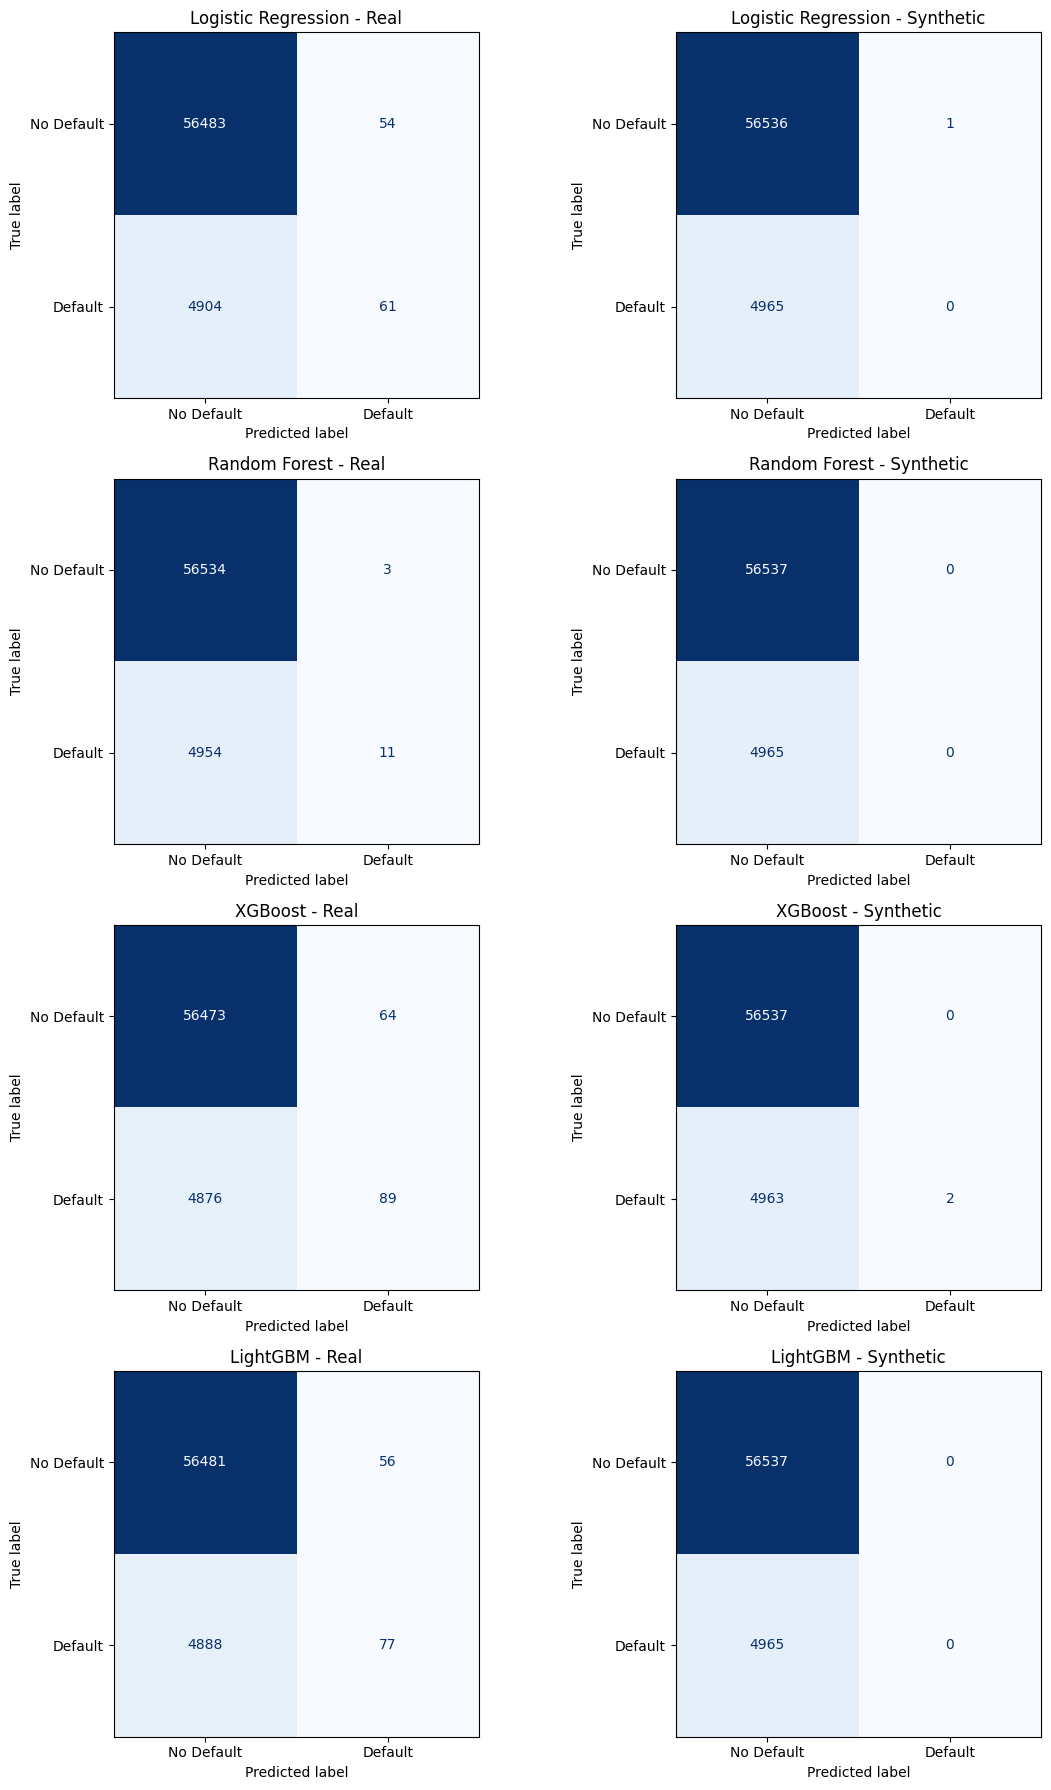

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

matrices_confusion = {
    "Logistic Regression - Real": cm_lr_real,
    "Logistic Regression - Synthetic": cm_lr_synth,
    "Random Forest - Real": cm_rf_real,
    "Random Forest - Synthetic": cm_rf_synth,
    "XGBoost - Real": cm_xgb_real,
    "XGBoost - Synthetic": cm_xgb_synth,
    "LightGBM - Real": cm_lgbm_real,
    "LightGBM - Synthetic": cm_lgbm_synth
}

fig, axes = plt.subplots(4, 2, figsize=(12, 18))

for ax, (titulo, matriz) in zip(axes.flatten(), matrices_confusion.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["No Default", "Default"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(titulo)

plt.tight_layout()
plt.show()

###### 7.4.4.1 Interpretación de las matrices de confusión

Las matrices de confusión muestran un comportamiento fuertemente orientado hacia la predicción de la clase mayoritaria (no-default) cuando se utiliza un umbral de clasificación de 0.50.

En los modelos entrenados con datos reales, Logistic Regression identificó correctamente 61 casos de default, Random Forest 11, XGBoost 89 y LightGBM 77, sobre un total de 4 965 observaciones positivas presentes en el conjunto de prueba. XGBoost presentó el mayor número de verdaderos positivos, aunque la proporción de defaults identificados continuó siendo reducida.

El comportamiento fue todavía más restrictivo en los modelos entrenados con datos sintéticos. Logistic Regression realizó una única predicción positiva, correspondiente a un falso positivo; Random Forest y LightGBM clasificaron todas las observaciones como no-default; y XGBoost realizó únicamente dos predicciones positivas, ambas correctamente clasificadas.

Este comportamiento es consistente con el análisis previo de las probabilidades estimadas, donde se observó que los modelos entrenados con Gaussian Copula V2.1 producen probabilidades menos extremas sobre el conjunto real de prueba. Como consecuencia, muy pocas observaciones alcanzan el umbral de 0.50.

Las matrices de confusión deben interpretarse conjuntamente con ROC-AUC y PR-AUC. Aunque los modelos sintéticos presentan una capacidad limitada para producir clasificaciones positivas con el umbral utilizado, varios de ellos mantienen una capacidad discriminativa relevante al considerar las probabilidades estimadas de forma continua.

Estos resultados justifican que la comparación inicial de modelos se base principalmente en ROC-AUC y PR-AUC, reservando el análisis del umbral de clasificación para la etapa posterior de optimización.

##### 7.4.5 Curvas ROC

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

###### 7.4.5.1 Curvas ROC — entrenamiento Real

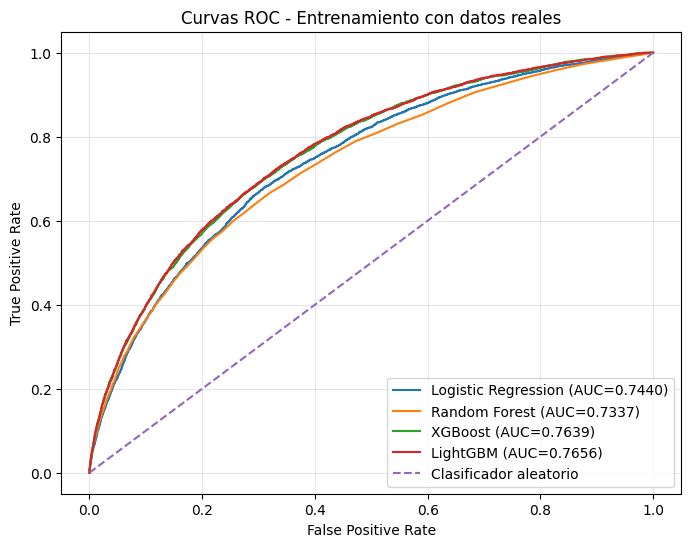

In [ ]:
plt.figure(figsize=(8, 6))

modelos_real_roc = {
    "Logistic Regression": probabilidades["LR_Real"],
    "Random Forest": probabilidades["RF_Real"],
    "XGBoost": probabilidades["XGB_Real"],
    "LightGBM": probabilidades["LGBM_Real"]
}

for nombre, probs in modelos_real_roc.items():

    fpr, tpr, _ = roc_curve(
        y_test_real,
        probs
    )

    auc = roc_auc_score(
        y_test_real,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Entrenamiento con datos reales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

###### 7.4.5.2 Curvas ROC — entrenamiento Synthetic

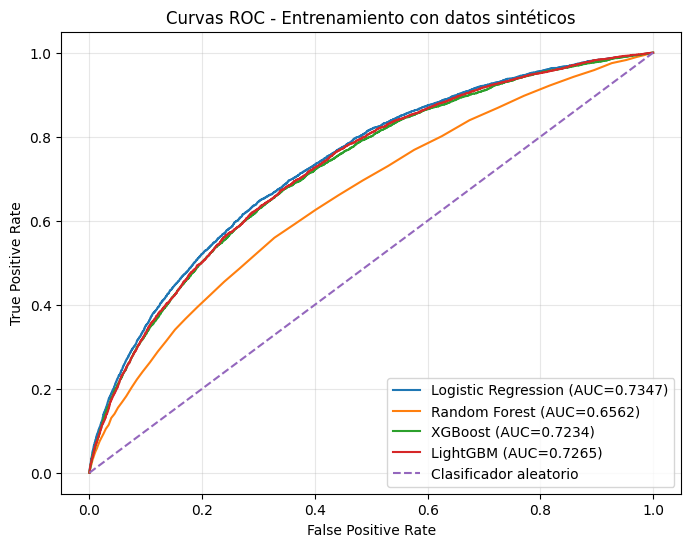

In [ ]:
plt.figure(figsize=(8, 6))

modelos_synth_roc = {
    "Logistic Regression": probabilidades["LR_Synthetic"],
    "Random Forest": probabilidades["RF_Synthetic"],
    "XGBoost": probabilidades["XGB_Synthetic"],
    "LightGBM": probabilidades["LGBM_Synthetic"]
}

for nombre, probs in modelos_synth_roc.items():

    fpr, tpr, _ = roc_curve(
        y_test_real,
        probs
    )

    auc = roc_auc_score(
        y_test_real,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curvas ROC - Entrenamiento con datos sintéticos"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

Real: LightGBM y XGBoost deberían aparecer prácticamente superpuestos como mejores modelos.

Synthetic: Logistic Regression debería quedar por encima en buena parte de la curva, seguida por LightGBM/XGBoost y finalmente Random Forest.

###### 7.4.5.3 Interpretación de las curvas ROC

Las curvas ROC confirman las diferencias observadas mediante ROC-AUC entre los modelos evaluados.

Cuando el entrenamiento se realiza con datos reales, LightGBM y XGBoost presentan las curvas con mayor capacidad discriminativa y un comportamiento muy similar, alcanzando ROC-AUC de 0.765594 y 0.763883, respectivamente. Logistic Regression presenta un rendimiento ligeramente inferior (0.744036), mientras que Random Forest obtiene el menor ROC-AUC (0.733735).

Al utilizar datos sintéticos para el entrenamiento se modifica el orden relativo de los algoritmos. Logistic Regression presenta la mayor capacidad discriminativa, con un ROC-AUC de 0.734700, seguida por LightGBM (0.726511) y XGBoost (0.723400). Random Forest presenta una reducción más pronunciada, alcanzando un ROC-AUC de 0.656235.

La comparación visual confirma que el efecto de sustituir los datos reales de entrenamiento por datos sintéticos no es uniforme entre algoritmos. Logistic Regression presenta la mayor estabilidad entre ambos escenarios, mientras que Random Forest experimenta la mayor pérdida de capacidad discriminativa.

##### 7.4.6 Curvas Precision-Recall

In [ ]:
#Estas son especialmente importantes por el desbalance de TARGET.
from sklearn.metrics import precision_recall_curve, average_precision_score

###### 7.4.6.1 Curvas Precision-Recall — entrenamiento Real

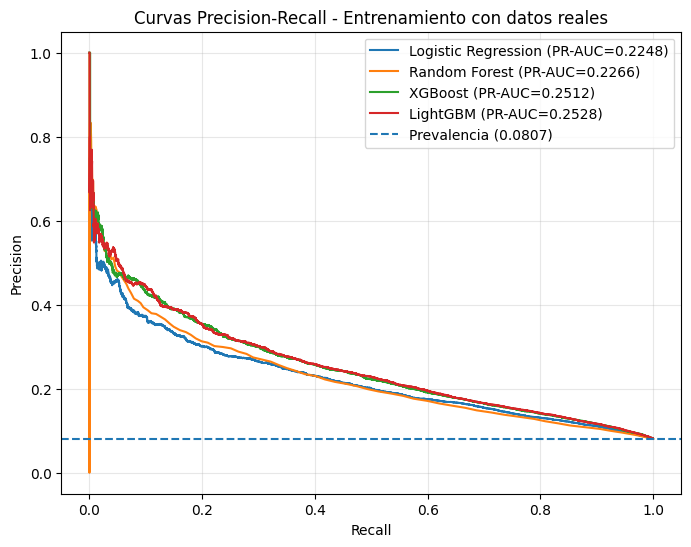

In [ ]:
plt.figure(figsize=(8, 6))

for nombre, probs in modelos_real_roc.items():

    precision, recall, _ = precision_recall_curve(
        y_test_real,
        probs
    )

    pr_auc = average_precision_score(
        y_test_real,
        probs
    )

    plt.plot(
        recall,
        precision,
        label=f"{nombre} (PR-AUC={pr_auc:.4f})"
    )

baseline = y_test_real.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Prevalencia ({baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Curvas Precision-Recall - Entrenamiento con datos reales"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

La línea de prevalencia de aproximadamente 0.0807 es importante: representa la referencia de un clasificador sin capacidad discriminativa en este contexto.

###### 7.4.6.2 Curvas Precision-Recall — entrenamiento Synthetic

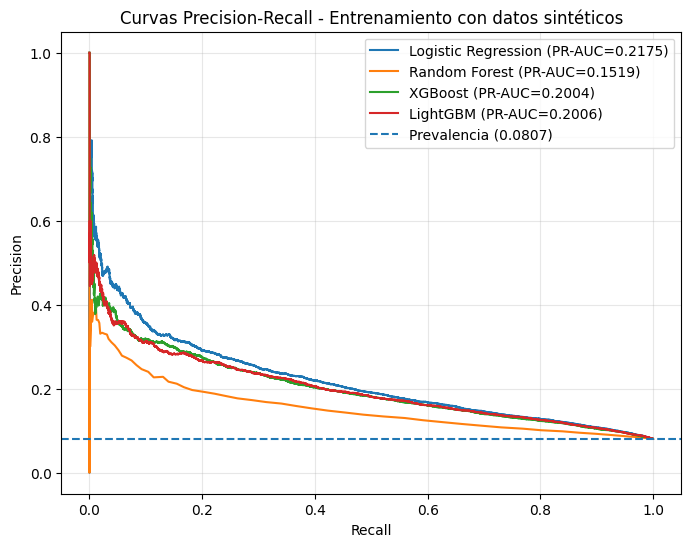

In [ ]:
plt.figure(figsize=(8, 6))

for nombre, probs in modelos_synth_roc.items():

    precision, recall, _ = precision_recall_curve(
        y_test_real,
        probs
    )

    pr_auc = average_precision_score(
        y_test_real,
        probs
    )

    plt.plot(
        recall,
        precision,
        label=f"{nombre} (PR-AUC={pr_auc:.4f})"
    )

baseline = y_test_real.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Prevalencia ({baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Curvas Precision-Recall - Entrenamiento con datos sintéticos"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

###### 7.4.6.3 Interpretación de las curvas Precision-Recall

Las curvas Precision-Recall permiten analizar con mayor detalle el comportamiento de los modelos sobre la clase minoritaria, aspecto especialmente relevante debido a que los casos de default representan aproximadamente el 8.07 % del conjunto real de prueba.

En el escenario de entrenamiento real, LightGBM obtiene el mayor PR-AUC (0.252761), seguido muy de cerca por XGBoost (0.251195). Random Forest alcanza 0.226612 y Logistic Regression 0.224755. Todos los modelos se encuentran claramente por encima de la prevalencia de la clase positiva, utilizada como referencia.

En el escenario sintético, Logistic Regression presenta el mayor PR-AUC (0.217511), seguida por LightGBM (0.200567) y XGBoost (0.200403), mientras que Random Forest obtiene el menor valor (0.151885). A pesar de la reducción respecto al entrenamiento real, todos los modelos continúan superando la prevalencia de la clase positiva.

Las curvas Precision-Recall confirman, por tanto, que los modelos entrenados con datos sintéticos conservan capacidad para priorizar observaciones de mayor riesgo, aunque esta capacidad varía según el algoritmo. Logistic Regression vuelve a presentar la menor pérdida entre los escenarios Real y Synthetic.

##### 7.4.7 Síntesis de la comparación Real vs Synthetic

| Modelo              |  ROC Real | ROC Synth |   Gap ROC |   PR Real |  PR Synth |    Gap PR |
| ------------------- | --------: | --------: | --------: | --------: | --------: | --------: |
| Logistic Regression |     .7440 | **.7347** | **.0093** |     .2248 | **.2175** | **.0072** |
| Random Forest       |     .7337 |     .6562 |     .0775 |     .2266 |     .1519 |     .0747 |
| XGBoost             |     .7639 |     .7234 |     .0405 |     .2512 |     .2004 |     .0508 |
| LightGBM            | **.7656** |     .7265 |     .0391 | **.2528** |     .2006 |     .0522 |


La evaluación conjunta de los cuatro algoritmos muestra que la sustitución de los datos reales de entrenamiento por Gaussian Copula V2.1 produce una reducción de rendimiento cuya magnitud depende del algoritmo utilizado.

Cuando se utilizan datos reales, LightGBM presenta el mayor rendimiento global, alcanzando un ROC-AUC de 0.765594 y un PR-AUC de 0.252761. XGBoost obtiene resultados prácticamente equivalentes, con un ROC-AUC de 0.763883 y un PR-AUC de 0.251195.

Cuando el entrenamiento se realiza con datos sintéticos, Logistic Regression obtiene el mayor rendimiento, alcanzando un ROC-AUC de 0.734700 y un PR-AUC de 0.217511. Asimismo, presenta la menor diferencia entre los escenarios Real y Synthetic, con reducciones de únicamente 0.009336 en ROC-AUC y 0.007244 en PR-AUC.

Random Forest presenta la mayor sensibilidad al cambio de fuente de entrenamiento, con una reducción de 0.077500 en ROC-AUC y 0.074726 en PR-AUC. XGBoost y LightGBM muestran un comportamiento intermedio, conservando aproximadamente el 94.70 % y 94.90 % de sus respectivos ROC-AUC obtenidos con datos reales.

Las métricas dependientes del umbral muestran un comportamiento diferente. Utilizando un punto de corte fijo de 0.50, todos los modelos presentan un Recall reducido sobre la clase default, especialmente aquellos entrenados con datos sintéticos. El análisis de las distribuciones de probabilidad mostró que los modelos sintéticos generan predicciones menos extremas, provocando que pocas o ninguna observación supere dicho umbral.

En conjunto, los resultados permiten concluir que Gaussian Copula V2.1 conserva información predictiva aprovechable por diferentes algoritmos, aunque el grado de transferencia depende del modelo utilizado. Logistic Regression presenta la mayor estabilidad ante la sustitución de datos reales por sintéticos, mientras que LightGBM presenta la mayor capacidad predictiva absoluta cuando se dispone de datos reales.

Estos resultados evidencian que la utilidad predictiva de un conjunto sintético debe evaluarse considerando tanto las propiedades del sintetizador como el modelo predictivo utilizado posteriormente.

#### 7.5 Optimización del modelo seleccionado

##### 7.5.1 Selección de candidatos para optimización

A partir de la comparación inicial se seleccionan Logistic Regression y LightGBM como candidatos para la etapa de optimización.

LightGBM es seleccionado por presentar el mayor rendimiento cuando el entrenamiento se realiza con datos reales, alcanzando un ROC-AUC de 0.765594 y un PR-AUC de 0.252761.

Logistic Regression es seleccionado por presentar la mayor utilidad predictiva cuando el entrenamiento se realiza con datos sintéticos, con un ROC-AUC de 0.734700 y un PR-AUC de 0.217511, así como la menor pérdida de rendimiento entre los escenarios Real y Synthetic.

La selección de ambos modelos permite estudiar dos propiedades complementarias: la capacidad predictiva absoluta y la estabilidad frente a la sustitución de datos reales por datos sintéticos.

La optimización se realizará utilizando exclusivamente información disponible durante el entrenamiento, manteniendo el conjunto real de prueba sin utilizar para la selección de hiperparámetros, umbrales o configuraciones. De esta manera, el conjunto de prueba continuará funcionando como referencia independiente para la evaluación final.

##### 7.5.2 Estrategia de optimización

La optimización se realizará sobre Logistic Regression y LightGBM, seleccionados en la etapa anterior por representar dos comportamientos complementarios: Logistic Regression presentó la mayor estabilidad ante la sustitución de datos reales por datos sintéticos, mientras que LightGBM alcanzó el mayor rendimiento predictivo cuando fue entrenado con datos reales.

La selección de hiperparámetros se realizará exclusivamente sobre los conjuntos de entrenamiento mediante validación cruzada estratificada, evitando utilizar el conjunto real de prueba durante el proceso de optimización.

ROC-AUC se utilizará como criterio principal de selección debido a su capacidad para evaluar la discriminación del modelo independientemente de un umbral específico. PR-AUC se utilizará posteriormente como métrica complementaria debido al desbalance existente en TARGET.

La optimización se realizará independientemente para los escenarios Real y Synthetic. De esta forma, cada modelo podrá seleccionar su configuración utilizando únicamente la fuente de información disponible durante su entrenamiento.

Una vez seleccionados los hiperparámetros, los modelos optimizados serán evaluados sobre el mismo conjunto real de prueba utilizado durante el benchmark inicial. Posteriormente se analizará el efecto del umbral de clasificación mediante información de validación, sin seleccionar dicho umbral utilizando el conjunto real de prueba.

##### 7.5.3 Configuración de la validación cruzada

In [ ]:
# Con ~246k registros, no considero necesario hacer 10 folds. 3 folds es suficiente para nuestro objetivo y reduce considerablemente el coste.
from sklearn.model_selection import StratifiedKFold

cv_estratificada = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print(cv_estratificada)

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


¿Por qué estratificada?

Porque queremos que cada fold conserve aproximadamente:

TARGET = 0 → 91.93 %
TARGET = 1 →  8.07 %

evitando variaciones innecesarias en la clase minoritaria.

##### 7.5.4 Optimización de Logistic Regression

Aquí no hay que probar decenas de parámetros.

Los principales que nos interesan son:

C: intensidad inversa de regularización.
class_weight: tratamiento del desbalance.

Y esta segunda variable es particularmente interesante debido a lo que acabamos de observar con threshold 0.50.

###### 7.5.4.1 Espacio de hiperparámetros

In [ ]:
param_grid_lr = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "class_weight": [None, "balanced"]
}

Son solamente 8 configuraciones × 3 folds = 24 ajustes por escenario.

Es manejable.

No optimizaremos el threshold todavía.

###### 7.5.4.2 Optimización — escenario Real

Como ya tenemos los datos escalados:

X_train_real_lr

podemos utilizar directamente GridSearchCV.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

grid_lr_real = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv_estratificada,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_lr_real.fit(
    X_train_real_lr,
    y_train_real
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=2000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1.0, 10.0],
                         'class_weight': [None, 'balanced']},
             scoring='roc_auc', verbose=1)

In [ ]:
print("Mejores hiperparámetros - LR Real:")
print(grid_lr_real.best_params_)

print(
    "ROC-AUC CV - LR Real:",
    round(grid_lr_real.best_score_, 6)
)

Mejores hiperparámetros - LR Real:
{'C': 0.01, 'class_weight': 'balanced'}
ROC-AUC CV - LR Real: 0.74306


Hasta ahora habíamos transformado:

X_train_real

antes de la validación cruzada.

Eso significa que StandardScaler y OneHotEncoder fueron ajustados sobre todo X_train_real antes de crear los folds.

Para el benchmark inicial eso no contaminaba el test real, pero para hacer tuning con validación cruzada de forma rigurosa, es mejor que el preprocesamiento ocurra dentro de cada fold.

Por tanto, para 7.5 vamos a mejorar esto usando un Pipeline.

No utilices el código anterior de grid_lr_real. Déjalo fuera. Utilicemos directamente la versión rigurosa siguiente.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr_cv = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numerical_cols
        )
    ]
)

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor_lr_cv),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

In [ ]:
grid_lr_real = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv_estratificada,
    n_jobs=-1,
    verbose=1
)

grid_lr_real.fit(
    X_train_real,
    y_train_real
)

print("Mejores hiperparámetros - LR Real")
print(grid_lr_real.best_params_)

print(
    "ROC-AUC CV:",
    round(grid_lr_real.best_score_, 6)
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros - LR Real
{'model__C': 0.01, 'model__class_weight': 'balanced'}
ROC-AUC CV: 0.743078


Ahora cada fold hace:

Train fold
   ↓
fit OneHotEncoder
fit StandardScaler
   ↓
fit Logistic Regression
   ↓
Validation fold

Esto es metodológicamente más limpio.

###### 7.5.4.3 Optimización — escenario Synthetic

In [ ]:
grid_lr_synth = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv_estratificada,
    n_jobs=-1,
    verbose=1
)

grid_lr_synth.fit(
    X_train_synth,
    y_train_synth
)

print("Mejores hiperparámetros - LR Synthetic")
print(grid_lr_synth.best_params_)

print(
    "ROC-AUC CV:",
    round(grid_lr_synth.best_score_, 6)
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores hiperparámetros - LR Synthetic
{'model__C': 0.01, 'model__class_weight': None}
ROC-AUC CV: 0.624455


###### 7.5.4.4 Resultados completos de la búsqueda

Además del ganador, quiero guardar los resultados para que podamos comprobar que no estamos eligiendo una configuración por diferencias insignificantes.

In [ ]:
resultados_cv_lr_real = pd.DataFrame(
    grid_lr_real.cv_results_
)[
    [
        "param_model__C",
        "param_model__class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

resultados_cv_lr_synth = pd.DataFrame(
    grid_lr_synth.cv_results_
)[
    [
        "param_model__C",
        "param_model__class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

In [ ]:
print("=== Logistic Regression - REAL ===")
display(resultados_cv_lr_real.round(6))

print("\n=== Logistic Regression - SYNTHETIC ===")
display(resultados_cv_lr_synth.round(6))

=== Logistic Regression - REAL ===


,param_model__C,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
1,0.01,balanced,0.743078,0.002766,1
0,0.01,None,0.742854,0.002918,2
3,0.10,balanced,0.742817,0.002439,3
2,0.10,None,0.742815,0.002581,4
4,1.00,None,0.742648,0.002478,5
5,1.00,balanced,0.742592,0.002407,6
7,10.00,balanced,0.742574,0.002404,7
6,10.00,None,0.742405,0.002287,8



=== Logistic Regression - SYNTHETIC ===


,param_model__C,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
0,0.01,None,0.624455,0.002550,1
1,0.01,balanced,0.623943,0.002351,2
2,0.10,None,0.623650,0.002543,3
4,1.00,None,0.623400,0.002543,4
6,10.00,None,0.623388,0.002445,5
3,0.10,balanced,0.623074,0.002231,6
5,1.00,balanced,0.622737,0.002212,7
7,10.00,balanced,0.622730,0.002175,8


anteriormente encontramos:

LR Real
ROC-AUC = 0.744036

LR Synthetic
ROC-AUC = 0.734700

La pregunta ahora no es simplemente:

¿sube el AUC después del tuning?

También queremos saber:

¿la gran estabilidad Real→Synthetic de Logistic Regression se mantiene después de optimizar ambos escenarios de manera independiente?

Eso es mucho más interesante para tu investigación.

Y class_weight="balanced" podría cambiar muchísimo Recall/Precision a threshold 0.50 sin necesariamente producir grandes cambios en ROC-AUC. Si ocurre, tendremos una demostración clara de que:

capacidad discriminativa y regla de clasificación son propiedades relacionadas pero distintas.

###### 7.5.4.5 Interpretación de la optimización de Logistic Regression

| Escenario CV  |    C | class_weight |   ROC-AUC CV |
| ------------- | ---: | ------------ | -----------: |
| **Real**      | 0.01 | balanced     | **0.743078** |
| **Synthetic** | 0.01 | None         | **0.624455** |


La optimización mediante validación cruzada seleccionó una regularización C = 0.01 en ambos escenarios. Para el entrenamiento real, la configuración mejor posicionada incorporó class_weight="balanced" y obtuvo un ROC-AUC medio de 0.743078. Para el entrenamiento sintético, la mejor configuración utilizó class_weight=None y alcanzó un ROC-AUC medio de 0.624455.

Las diferencias entre las primeras configuraciones fueron reducidas. En el escenario real, la diferencia entre las dos mejores configuraciones fue de 0.000224 de ROC-AUC, mientras que en el escenario sintético fue de 0.000512. Estas diferencias son inferiores a la variabilidad observada entre folds, por lo que la selección de class_weight no debe interpretarse como una mejora sustancial de la capacidad discriminativa.

En cambio, C = 0.01 ocupó las primeras posiciones en ambos escenarios, sugiriendo que una regularización más fuerte resulta ligeramente favorable para Logistic Regression bajo el protocolo evaluado.

Resulta especialmente relevante la diferencia entre el ROC-AUC obtenido mediante validación cruzada sobre datos sintéticos (0.624455) y el rendimiento previamente observado al entrenar con datos sintéticos y evaluar sobre datos reales (0.734700). Ambos resultados corresponden a escenarios distintos: el primero mide la discriminación interna dentro del conjunto sintético, mientras que el segundo mide la transferencia de las relaciones aprendidas desde los datos sintéticos hacia observaciones reales.

Este comportamiento es consistente con los resultados obtenidos previamente para Gaussian Copula V2.1, donde la utilidad predictiva interna y la capacidad de transferencia hacia datos reales presentaron diferencias. Por tanto, el rendimiento interno sobre datos sintéticos no debe utilizarse de forma aislada para inferir su utilidad como sustituto de entrenamiento sobre datos reales.

##### 7.5.5 Optimización de LightGBM

Aquí debemos evitar una búsqueda gigantesca. Tenemos 246k registros, por lo que utilizaremos una cuadrícula reducida sobre parámetros relevantes.

###### 7.5.5.1 Espacio de hiperparámetros

In [ ]:
param_grid_lgbm = {
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 8],
    "model__min_child_samples": [20, 50],
    "model__class_weight": [None, "balanced"]
}

Eso son:

3 × 2 × 2 × 2 = 24 configuraciones

con 3 folds:

72 fits por escenario.

Es razonable, pero dos escenarios implican 144 entrenamientos.

Para no hacer una búsqueda innecesariamente costosa, prefiero RandomizedSearchCV con 12 configuraciones por escenario, manteniendo la misma CV estratificada.

###### 7.5.5.2 Pipeline de LightGBM

In [ ]:
#Aquí tampoco escalamos numéricas:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_tree_cv = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

pipeline_lgbm = Pipeline([
    ("preprocessor", preprocessor_tree_cv),
    (
        "model",
        LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

Mantenemos n_estimators=200 y learning_rate=0.05 fijos inicialmente porque ya forman parte de nuestra configuración base. El tuning se concentra en la complejidad estructural del árbol y el tratamiento de la clase.

###### 7.5.5.3 Optimización — escenario Real

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_lgbm = {
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 8],
    "model__min_child_samples": [20, 50],
    "model__class_weight": [None, "balanced"]
}

search_lgbm_real = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=12,
    scoring="roc_auc",
    cv=cv_estratificada,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_lgbm_real.fit(
    X_train_real,
    y_train_real
)

print("Mejores hiperparámetros - LightGBM Real")
print(search_lgbm_real.best_params_)

print(
    "ROC-AUC CV:",
    round(search_lgbm_real.best_score_, 6)
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros - LightGBM Real
{'model__num_leaves': 63, 'model__min_child_samples': 20, 'model__max_depth': 8, 'model__class_weight': None}
ROC-AUC CV: 0.760144


###### 7.5.5.4 Optimización — escenario Synthetic

In [ ]:
search_lgbm_synth = RandomizedSearchCV(
    estimator=pipeline_lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=12,
    scoring="roc_auc",
    cv=cv_estratificada,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_lgbm_synth.fit(
    X_train_synth,
    y_train_synth
)

print("Mejores hiperparámetros - LightGBM Synthetic")
print(search_lgbm_synth.best_params_)

print(
    "ROC-AUC CV:",
    round(search_lgbm_synth.best_score_, 6)
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores hiperparámetros - LightGBM Synthetic
{'model__num_leaves': 15, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__class_weight': None}
ROC-AUC CV: 0.619811


###### 7.5.5.5 Resultados de la búsqueda

In [ ]:
columnas_lgbm_cv = [
    "param_model__num_leaves",
    "param_model__max_depth",
    "param_model__min_child_samples",
    "param_model__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

resultados_cv_lgbm_real = (
    pd.DataFrame(search_lgbm_real.cv_results_)
    [columnas_lgbm_cv]
    .sort_values("rank_test_score")
)

resultados_cv_lgbm_synth = (
    pd.DataFrame(search_lgbm_synth.cv_results_)
    [columnas_lgbm_cv]
    .sort_values("rank_test_score")
)

print("=== LightGBM - REAL ===")
display(
    resultados_cv_lgbm_real.round(6)
)

print("\n=== LightGBM - SYNTHETIC ===")
display(
    resultados_cv_lgbm_synth.round(6)
)

=== LightGBM - REAL ===


,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
0,63,8,20,None,0.760144,0.002379,1
1,31,-1,50,balanced,0.760075,0.002398,2
9,63,-1,50,None,0.759976,0.002637,3
4,63,8,50,None,0.759913,0.002470,4
7,31,-1,20,None,0.759841,0.002604,5
6,31,-1,20,balanced,0.759755,0.002287,6
5,15,8,50,None,0.759477,0.002592,7
3,15,8,20,balanced,0.759363,0.002903,8
2,15,-1,20,None,0.759348,0.002388,9
8,15,8,50,balanced,0.759318,0.003062,10



=== LightGBM - SYNTHETIC ===


,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__class_weight,mean_test_score,std_test_score,rank_test_score
2,15,-1,20,None,0.619811,0.003340,1
5,15,8,50,None,0.619641,0.002956,2
8,15,8,50,balanced,0.619029,0.003441,3
3,15,8,20,balanced,0.619013,0.003199,4
11,15,-1,20,balanced,0.618559,0.003196,5
7,31,-1,20,None,0.617133,0.003786,6
1,31,-1,50,balanced,0.614573,0.002612,7
6,31,-1,20,balanced,0.614571,0.004298,8
9,63,-1,50,None,0.613657,0.003023,9
0,63,8,20,None,0.612733,0.003809,10


Aquí hay una comparación especialmente interesante con Logistic Regression.

LR nos dio:

CV Real ≈ 0.7431
CV Synthetic ≈ 0.6245

Si LightGBM Synthetic también presenta un CV interno relativamente bajo, pero posteriormente vuelve a obtener alrededor de 0.72 sobre el test real, tendremos evidencia adicional del patrón TSTS < TSTR de Gaussian Copula.

Además, veremos si class_weight="balanced" mejora el ranking o simplemente modifica posteriormente el comportamiento del threshold.

###### 7.5.5.6 Interpretación de la optimización de LightGBM

| Escenario     | num_leaves | max_depth | min_child_samples | class_weight |   ROC-AUC CV |
| ------------- | ---------: | --------: | ----------------: | ------------ | -----------: |
| **Real**      |         63 |         8 |                20 | None         | **0.760144** |
| **Synthetic** |         15 |        -1 |                20 | None         | **0.619811** |


La optimización de LightGBM mediante validación cruzada produjo configuraciones diferentes para los escenarios Real y Synthetic.

En el escenario real, la mejor configuración utilizó 63 hojas, una profundidad máxima de 8, 20 observaciones mínimas por hoja y ausencia de ponderación automática de clases, alcanzando un ROC-AUC medio de 0.760144.

En el escenario sintético, la configuración mejor posicionada utilizó 15 hojas, profundidad sin restricción explícita, 20 observaciones mínimas por hoja y ausencia de ponderación de clases, obteniendo un ROC-AUC medio de 0.619811.

Las diferencias entre las primeras configuraciones fueron reducidas. En el escenario real, las dos mejores alternativas difirieron únicamente en 0.000069 de ROC-AUC, mientras que en el escenario sintético la diferencia entre las dos primeras fue de 0.000170. Por tanto, el orden obtenido mediante la búsqueda no debe interpretarse como evidencia de grandes diferencias entre configuraciones próximas.

La selección de un menor número de hojas en el escenario sintético muestra que, bajo el procedimiento de validación utilizado, una estructura menos compleja resultó más favorable para la discriminación interna del conjunto Gaussian Copula V2.1. No obstante, este resultado no permite atribuir causalmente dicha preferencia a una propiedad específica del proceso generativo.

Asimismo, class_weight="balanced" no fue seleccionado en ninguno de los dos escenarios, indicando que su incorporación no produjo una mejora del ROC-AUC suficiente para superar las configuraciones sin ponderación dentro del espacio de búsqueda evaluado.

Finalmente, el ROC-AUC interno del escenario sintético (0.619811) vuelve a ser considerablemente inferior al rendimiento observado previamente cuando un LightGBM entrenado con Gaussian Copula V2.1 fue evaluado sobre datos reales. Este resultado refuerza la distinción entre utilidad predictiva interna del conjunto sintético y capacidad de transferencia hacia observaciones reales.

##### 7.5.6 Evaluación de los modelos optimizados sobre el conjunto real de prueba

Ahora sí vamos a utilizar nuevamente nuestro test real.

Tenemos cuatro ganadores:

LR Real optimizada
LR Synthetic optimizada
LightGBM Real optimizado
LightGBM Synthetic optimizado

Los objetos GridSearchCV/RandomizedSearchCV ya han hecho refit=True por defecto, por lo que best_estimator_ está entrenado nuevamente utilizando todo su conjunto de entrenamiento con la configuración ganadora.

###### 7.5.6.1 Recuperación de modelos optimizados

In [ ]:
lr_real_opt = grid_lr_real.best_estimator_
lr_synth_opt = grid_lr_synth.best_estimator_

lgbm_real_opt = search_lgbm_real.best_estimator_
lgbm_synth_opt = search_lgbm_synth.best_estimator_

###### 7.5.6.2 Evaluación común

In [ ]:
#NComo estos objetos son Pipeline, reciben directamente las 39 variables originales.
resultado_lr_real_opt, cm_lr_real_opt = evaluar_modelo(
    nombre_modelo="Logistic Regression Optimized",
    fuente_entrenamiento="Real",
    modelo=lr_real_opt,
    X_test=X_test_real,
    y_test=y_test_real
)

resultado_lr_synth_opt, cm_lr_synth_opt = evaluar_modelo(
    nombre_modelo="Logistic Regression Optimized",
    fuente_entrenamiento="Synthetic",
    modelo=lr_synth_opt,
    X_test=X_test_real,
    y_test=y_test_real
)

resultado_lgbm_real_opt, cm_lgbm_real_opt = evaluar_modelo(
    nombre_modelo="LightGBM Optimized",
    fuente_entrenamiento="Real",
    modelo=lgbm_real_opt,
    X_test=X_test_real,
    y_test=y_test_real
)

resultado_lgbm_synth_opt, cm_lgbm_synth_opt = evaluar_modelo(
    nombre_modelo="LightGBM Optimized",
    fuente_entrenamiento="Synthetic",
    modelo=lgbm_synth_opt,
    X_test=X_test_real,
    y_test=y_test_real
)


###### 7.5.6.3 Tabla de resultados optimizados

In [ ]:
resultados_optimizados = pd.DataFrame([
    resultado_lr_real_opt,
    resultado_lr_synth_opt,
    resultado_lgbm_real_opt,
    resultado_lgbm_synth_opt
])

resultados_optimizados.round(6)

,Modelo,Entrenamiento,ROC_AUC,PR_AUC,Precision,Recall,F1
0,Logistic Regression Optimized,Real,0.744185,0.223673,0.161441,0.677140,0.260721
1,Logistic Regression Optimized,Synthetic,0.735445,0.217738,0.000000,0.000000,0.000000
2,LightGBM Optimized,Real,0.764858,0.253704,0.558659,0.020141,0.038880
3,LightGBM Optimized,Synthetic,0.728760,0.206189,1.000000,0.000201,0.000403


In [ ]:
#MAtrices
print("=== Logistic Regression Optimized - REAL ===")
print(cm_lr_real_opt)

print("\n=== Logistic Regression Optimized - SYNTHETIC ===")
print(cm_lr_synth_opt)

print("\n=== LightGBM Optimized - REAL ===")
print(cm_lgbm_real_opt)

print("\n=== LightGBM Optimized - SYNTHETIC ===")
print(cm_lgbm_synth_opt)

=== Logistic Regression Optimized - REAL ===
[[39074 17463]
 [ 1603  3362]]

=== Logistic Regression Optimized - SYNTHETIC ===
[[56536     1]
 [ 4965     0]]

=== LightGBM Optimized - REAL ===
[[56458    79]
 [ 4865   100]]

=== LightGBM Optimized - SYNTHETIC ===
[[56537     0]
 [ 4964     1]]


###### 7.5.6.4 Comparación Baseline vs Optimized

In [ ]:
#Queremos saber si el tuning realmente aportó algo.
comparacion_optimizacion = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        "Entrenamiento": "Real",
        "ROC_AUC_Baseline": resultado_lr_real["ROC_AUC"],
        "ROC_AUC_Optimized": resultado_lr_real_opt["ROC_AUC"],
        "PR_AUC_Baseline": resultado_lr_real["PR_AUC"],
        "PR_AUC_Optimized": resultado_lr_real_opt["PR_AUC"]
    },
    {
        "Modelo": "Logistic Regression",
        "Entrenamiento": "Synthetic",
        "ROC_AUC_Baseline": resultado_lr_synth["ROC_AUC"],
        "ROC_AUC_Optimized": resultado_lr_synth_opt["ROC_AUC"],
        "PR_AUC_Baseline": resultado_lr_synth["PR_AUC"],
        "PR_AUC_Optimized": resultado_lr_synth_opt["PR_AUC"]
    },
    {
        "Modelo": "LightGBM",
        "Entrenamiento": "Real",
        "ROC_AUC_Baseline": resultado_lgbm_real["ROC_AUC"],
        "ROC_AUC_Optimized": resultado_lgbm_real_opt["ROC_AUC"],
        "PR_AUC_Baseline": resultado_lgbm_real["PR_AUC"],
        "PR_AUC_Optimized": resultado_lgbm_real_opt["PR_AUC"]
    },
    {
        "Modelo": "LightGBM",
        "Entrenamiento": "Synthetic",
        "ROC_AUC_Baseline": resultado_lgbm_synth["ROC_AUC"],
        "ROC_AUC_Optimized": resultado_lgbm_synth_opt["ROC_AUC"],
        "PR_AUC_Baseline": resultado_lgbm_synth["PR_AUC"],
        "PR_AUC_Optimized": resultado_lgbm_synth_opt["PR_AUC"]
    }
])

comparacion_optimizacion["Delta_ROC_AUC"] = (
    comparacion_optimizacion["ROC_AUC_Optimized"]
    - comparacion_optimizacion["ROC_AUC_Baseline"]
)

comparacion_optimizacion["Delta_PR_AUC"] = (
    comparacion_optimizacion["PR_AUC_Optimized"]
    - comparacion_optimizacion["PR_AUC_Baseline"]
)

comparacion_optimizacion.round(6)

,Modelo,Entrenamiento,ROC_AUC_Baseline,ROC_AUC_Optimized,PR_AUC_Baseline,PR_AUC_Optimized,Delta_ROC_AUC,Delta_PR_AUC
0,Logistic Regression,Real,0.744036,0.744185,0.224755,0.223673,0.000149,-0.001082
1,Logistic Regression,Synthetic,0.734700,0.735445,0.217511,0.217738,0.000745,0.000227
2,LightGBM,Real,0.765594,0.764858,0.252761,0.253704,-0.000736,0.000943
3,LightGBM,Synthetic,0.726511,0.728760,0.200567,0.206189,0.002249,0.005621


Los hiperparámetros fueron elegidos por desempeño medio en CV, no mirando el test. Esa es precisamente la metodología correcta.

Si por casualidad hubiéramos probado configuraciones repetidamente sobre el test hasta encontrar una que aumentara el AUC, entonces sí estaríamos sobreajustando nuestro experimento al test.

###### 7.5.6.5 Interpretación de los modelos optimizados

| Modelo   | Fuente    |    ROC base |    ROC opt. |        Δ ROC | PR base |     PR opt. |         Δ PR |
| -------- | --------- | ----------: | ----------: | -----------: | ------: | ----------: | -----------: |
| LR       | Real      |     .744036 |     .744185 |     +.000149 | .224755 |     .223673 |     -.001082 |
| LR       | Synthetic |     .734700 |     .735445 |     +.000745 | .217511 |     .217738 |     +.000227 |
| LightGBM | Real      | **.765594** |     .764858 |     -.000736 | .252761 | **.253704** |     +.000943 |
| LightGBM | Synthetic |     .726511 | **.728760** | **+.002249** | .200567 | **.206189** | **+.005621** |


La primera conclusión es bastante clara: no hubo una mejora sustancial de ROC-AUC mediante tuning.

Eso no es un problema. De hecho, es un resultado legítimo: las configuraciones baseline ya eran competitivas.

En LightGBM Synthetic sí tenemos la mejora más visible:

ROC: 0.726511 → 0.728760
PR: 0.200567 → 0.206189

pero sigue siendo moderada.

La optimización de hiperparámetros produjo cambios reducidos en la capacidad discriminativa de los modelos evaluados.

Logistic Regression entrenada con datos reales incrementó su ROC-AUC de 0.744036 a 0.744185, aunque su PR-AUC disminuyó ligeramente de 0.224755 a 0.223673. En el escenario sintético, el ROC-AUC aumentó de 0.734700 a 0.735445 y el PR-AUC de 0.217511 a 0.217738.

LightGBM entrenado con datos reales presentó una ligera reducción de ROC-AUC, de 0.765594 a 0.764858, acompañada de un incremento de PR-AUC de 0.252761 a 0.253704. El mayor efecto positivo de la optimización se observó en LightGBM entrenado con datos sintéticos, cuyo ROC-AUC aumentó de 0.726511 a 0.728760 y cuyo PR-AUC pasó de 0.200567 a 0.206189.

En conjunto, las variaciones observadas muestran que la optimización de hiperparámetros no modifica sustancialmente las conclusiones obtenidas durante el benchmark inicial. LightGBM continúa presentando la mayor capacidad predictiva cuando se utilizan datos reales, mientras que Logistic Regression continúa mostrando una elevada estabilidad frente a la sustitución de datos reales por datos sintéticos.

La ausencia de mejoras pronunciadas no debe interpretarse como un resultado negativo, dado que los hiperparámetros fueron seleccionados exclusivamente mediante validación cruzada sobre los conjuntos de entrenamiento. El conjunto real de prueba no fue utilizado para seleccionar configuraciones, preservando así su función como referencia para la evaluación final.

###### 7.5.6.6 Efecto de class_weight en Logistic Regression

Un resultado particularmente relevante se observa en Logistic Regression entrenada con datos reales. La configuración optimizada incorporó class_weight="balanced", provocando un cambio sustancial en las clasificaciones obtenidas con un umbral de 0.50.

El número de verdaderos positivos aumentó de 61 a 3 362 y el Recall pasó de 0.012286 a 0.677140. Sin embargo, simultáneamente los falsos positivos aumentaron de 54 a 17 463 y la Precision disminuyó de 0.530435 a 0.161441.

A pesar de este cambio pronunciado en las métricas dependientes del umbral, el ROC-AUC únicamente varió de 0.744036 a 0.744185. Esto evidencia que la ponderación de clases modificó principalmente la distribución de las probabilidades y la regla de decisión efectiva respecto al umbral de 0.50, sin producir una mejora equivalente en la capacidad global de ordenamiento del riesgo.

El resultado pone de manifiesto la importancia de diferenciar entre capacidad discriminativa y comportamiento de clasificación bajo un determinado punto de corte. En un problema de riesgo crediticio, incrementar la detección de defaults implica potencialmente aceptar un mayor número de falsos positivos, por lo que la selección del umbral depende del equilibrio entre ambos tipos de error y del contexto de decisión.

##### 7.5.7 Análisis del umbral de clasificación

Aquí modificaría ligeramente lo que habíamos pensado.

No considero conveniente que tu TFM busque ahora un supuesto “threshold óptimo” y lo presente como si fuera el umbral correcto para riesgo crediticio.

¿Por qué?

Porque el threshold correcto depende del coste relativo de:

conceder crédito a alguien que incumple;
rechazar a alguien que habría pagado;
política de riesgo;
rentabilidad;
apetito de riesgo.

Y nosotros no disponemos de esa función de costes.

Lo que sí podemos hacer científicamente es un análisis de sensibilidad al threshold.

Eso es mucho más defendible.

###### 7.5.7.1 Sensibilidad Precision-Recall al umbral

Para los dos modelos que probablemente utilizaremos después —LR y LightGBM— podemos observar thresholds sin seleccionar uno como “óptimo”.

Primero recuperemos probabilidades optimizadas:

In [ ]:
prob_lr_real_opt = lr_real_opt.predict_proba(
    X_test_real
)[:, 1]

prob_lr_synth_opt = lr_synth_opt.predict_proba(
    X_test_real
)[:, 1]

prob_lgbm_real_opt = lgbm_real_opt.predict_proba(
    X_test_real
)[:, 1]

prob_lgbm_synth_opt = lgbm_synth_opt.predict_proba(
    X_test_real
)[:, 1]

In [ ]:
#Funcion descriptiva
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluar_thresholds(y_true, y_prob, thresholds):

    filas = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        filas.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y_true, y_pred, zero_division=0
            ),
            "Recall": recall_score(
                y_true, y_pred, zero_division=0
            ),
            "F1": f1_score(
                y_true, y_pred, zero_division=0
            ),
            "Predicciones_positivas": y_pred.sum()
        })

    return pd.DataFrame(filas)

In [ ]:
#UTilzamos puntos descriptivos
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

In [ ]:
#Calculamos
sensibilidad_lr_real = evaluar_thresholds(
    y_test_real,
    prob_lr_real_opt,
    thresholds
)

sensibilidad_lr_synth = evaluar_thresholds(
    y_test_real,
    prob_lr_synth_opt,
    thresholds
)

sensibilidad_lgbm_real = evaluar_thresholds(
    y_test_real,
    prob_lgbm_real_opt,
    thresholds
)

sensibilidad_lgbm_synth = evaluar_thresholds(
    y_test_real,
    prob_lgbm_synth_opt,
    thresholds
)

In [ ]:
print("=== LR Optimized - REAL ===")
display(sensibilidad_lr_real.round(6))

print("\n=== LR Optimized - SYNTHETIC ===")
display(sensibilidad_lr_synth.round(6))

print("\n=== LightGBM Optimized - REAL ===")
display(sensibilidad_lgbm_real.round(6))

print("\n=== LightGBM Optimized - SYNTHETIC ===")
display(sensibilidad_lgbm_synth.round(6))

=== LR Optimized - REAL ===


,Threshold,Precision,Recall,F1,Predicciones_positivas
0,0.1,0.081785,0.997986,0.151180,60586
1,0.2,0.090273,0.974622,0.165241,53604
2,0.3,0.107363,0.915408,0.192186,42333
3,0.4,0.130074,0.807452,0.224054,30821
4,0.5,0.161441,0.677140,0.260721,20825



=== LR Optimized - SYNTHETIC ===


,Threshold,Precision,Recall,F1,Predicciones_positivas
0,0.1,0.165246,0.613092,0.260327,18421
1,0.2,0.360731,0.095468,0.150979,1314
2,0.3,0.593750,0.007654,0.015112,64
3,0.4,0.000000,0.000000,0.000000,2
4,0.5,0.000000,0.000000,0.000000,1



=== LightGBM Optimized - REAL ===


,Threshold,Precision,Recall,F1,Predicciones_positivas
0,0.1,0.190568,0.598187,0.289051,15585
1,0.2,0.296086,0.304733,0.300347,5110
2,0.3,0.392220,0.146224,0.213028,1851
3,0.4,0.475649,0.059013,0.104999,616
4,0.5,0.558659,0.020141,0.038880,179



=== LightGBM Optimized - SYNTHETIC ===


,Threshold,Precision,Recall,F1,Predicciones_positivas
0,0.1,0.164894,0.590131,0.257764,17769
1,0.2,0.358570,0.068681,0.115281,951
2,0.3,0.540541,0.004028,0.007997,37
3,0.4,1.000000,0.000403,0.000805,2
4,0.5,1.000000,0.000201,0.000403,1


Estas tablas son únicamente un análisis descriptivo de sensibilidad.

###### 7.5.7.2 Interpretación del análisis de sensibilidad al umbral

Los resultados muestran claramente que 0.50 no tiene un significado especial como umbral óptimo para este problema. Al reducir el threshold aumenta Recall a costa de Precision.

Un ejemplo muy claro es LightGBM Synthetic:

| Threshold | Precision |     Recall |         F1 |
| --------: | --------: | ---------: | ---------: |
|      0.10 |    0.1649 | **0.5901** | **0.2578** |
|      0.20 |    0.3586 |     0.0687 |     0.1153 |
|      0.30 |    0.5405 |     0.0040 |     0.0080 |
|      0.40 |    1.0000 |     0.0004 |     0.0008 |
|      0.50 |    1.0000 |     0.0002 |     0.0004 |


Por tanto, aquel Recall casi nulo que vimos a 0.50 no implica que LightGBM Synthetic sea incapaz de detectar defaults. A 0.10 recupera aproximadamente el 59% de ellos, aunque con Precision de solo 16.5%.

LR Synthetic presenta un comportamiento parecido: a 0.10 alcanza Recall 0.6131 y F1 0.2603.


El análisis de sensibilidad confirma que las métricas de clasificación dependen considerablemente del punto de corte utilizado para transformar las probabilidades estimadas en decisiones binarias.

Los modelos entrenados con datos sintéticos presentan una reducción particularmente pronunciada del Recall conforme aumenta el umbral. Por ejemplo, LightGBM Synthetic alcanza un Recall de 0.590131 con un umbral de 0.10, mientras que con 0.50 dicho valor disminuye hasta 0.000201. Logistic Regression Synthetic presenta un comportamiento similar, pasando de un Recall de 0.613092 a 0.000000.

Estos resultados confirman que el reducido número de predicciones positivas observado anteriormente con un umbral de 0.50 no implica ausencia de capacidad discriminativa. Los modelos conservan capacidad para priorizar observaciones de mayor riesgo, pero la escala de sus probabilidades provoca comportamientos de clasificación diferentes según el punto de corte utilizado.

Asimismo, se observa el compromiso esperado entre Precision y Recall. Umbrales menores permiten identificar una mayor proporción de defaults, pero incrementan simultáneamente el número de falsos positivos.

Dado que el presente trabajo no dispone de una función económica que determine el coste relativo de falsos positivos y falsos negativos, no se selecciona un umbral de decisión como óptimo. El análisis se utiliza únicamente para mostrar la sensibilidad de los resultados al punto de corte y evitar atribuir al valor 0.50 un significado operativo que no ha sido establecido en el diseño experimental.

##### 7.5.8 Evaluación de calibración

Tu objetivo habla de:

estimación de la Probabilidad de Default

No solamente de distinguir TARGET=0/1.

Por eso añadir Brier Score es metodológicamente coherente y bastante ligero.

Menor es mejor.

###### 7.5.8.1 Brier Score

In [ ]:
from sklearn.metrics import brier_score_loss

calibracion = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        "Entrenamiento": "Real",
        "Brier_Score": brier_score_loss(
            y_test_real,
            prob_lr_real_opt
        )
    },
    {
        "Modelo": "Logistic Regression",
        "Entrenamiento": "Synthetic",
        "Brier_Score": brier_score_loss(
            y_test_real,
            prob_lr_synth_opt
        )
    },
    {
        "Modelo": "LightGBM",
        "Entrenamiento": "Real",
        "Brier_Score": brier_score_loss(
            y_test_real,
            prob_lgbm_real_opt
        )
    },
    {
        "Modelo": "LightGBM",
        "Entrenamiento": "Synthetic",
        "Brier_Score": brier_score_loss(
            y_test_real,
            prob_lgbm_synth_opt
        )
    }
])

calibracion.round(6)

,Modelo,Entrenamiento,Brier_Score
0,Logistic Regression,Real,0.204056
1,Logistic Regression,Synthetic,0.070174
2,LightGBM,Real,0.067340
3,LightGBM,Synthetic,0.070604


Pero Brier combina calibración y discriminación; no basta para decir “está calibrado”. Por eso añadiremos también una curva.

###### 7.5.8.2 Curvas de calibración

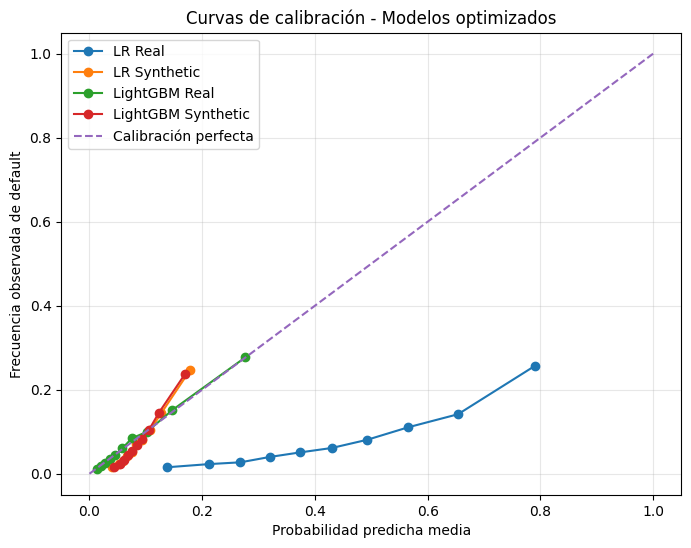

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

modelos_calibracion = {
    "LR Real": prob_lr_real_opt,
    "LR Synthetic": prob_lr_synth_opt,
    "LightGBM Real": prob_lgbm_real_opt,
    "LightGBM Synthetic": prob_lgbm_synth_opt
}

plt.figure(figsize=(8, 6))

for nombre, probs in modelos_calibracion.items():

    prob_true, prob_pred = calibration_curve(
        y_test_real,
        probs,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=nombre
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración perfecta"
)

plt.xlabel("Probabilidad predicha media")
plt.ylabel("Frecuencia observada de default")
plt.title("Curvas de calibración - Modelos optimizados")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

##

Aquí no esperamos necesariamente calibración perfecta. De hecho, class_weight="balanced" puede hacer que LR Real tenga una calibración bastante mala aunque su Recall a 0.50 haya aumentado muchísimo.

Y si eso ocurre, tendremos una lección importante:

un modelo puede discriminar razonablemente bien y al mismo tiempo producir probabilidades mal calibradas.

Eso es particularmente relevante cuando hablamos literalmente de PD.

###### 7.5.8.3 Interpretación de la calibración

La evaluación mediante Brier Score y curvas de calibración aporta una dimensión adicional al análisis, especialmente relevante debido a que el problema se formula como estimación de la Probabilidad de Default.

LightGBM entrenado con datos reales obtuvo el menor Brier Score (0.067340), seguido por Logistic Regression Synthetic (0.070174) y LightGBM Synthetic (0.070604). Logistic Regression entrenada con datos reales presentó un valor considerablemente superior (0.204056).

Este último comportamiento debe interpretarse considerando que la configuración optimizada de Logistic Regression Real utiliza class_weight="balanced". Aunque dicha configuración fue seleccionada mediante ROC-AUC y produjo un aumento sustancial del Recall utilizando un umbral de 0.50, la ponderación de clases modifica la escala de las probabilidades estimadas. La curva de calibración muestra una desviación pronunciada respecto a la diagonal de referencia, indicando que las probabilidades producidas por esta configuración no representan adecuadamente la frecuencia observada de default.

Este resultado evidencia que una configuración favorable para discriminación o para determinadas métricas de clasificación no necesariamente proporciona probabilidades adecuadamente calibradas.

Los modelos LightGBM Real, LightGBM Synthetic y Logistic Regression Synthetic presentan Brier Scores considerablemente menores y curvas más próximas a la referencia en el rango de probabilidades observado. No obstante, el Brier Score no constituye una medida pura de calibración, dado que combina componentes relacionados con calibración y discriminación, por lo que su interpretación se realiza conjuntamente con las curvas de calibración.

En consecuencia, la evaluación probabilística complementa las métricas ROC-AUC y PR-AUC y muestra la necesidad de diferenciar tres propiedades: capacidad discriminativa, comportamiento de clasificación bajo un umbral determinado y correspondencia entre las probabilidades estimadas y las frecuencias observadas.

##### 7.5.9 Conclusiones de la optimización

La optimización de Logistic Regression y LightGBM no produjo modificaciones sustanciales en las conclusiones obtenidas durante el benchmark inicial.

Logistic Regression mantuvo una elevada estabilidad frente a la sustitución de datos reales por sintéticos. Tras la optimización, el ROC-AUC obtenido mediante entrenamiento real fue de 0.744185, mientras que el entrenamiento sintético alcanzó 0.735445.

LightGBM continuó presentando la mayor capacidad discriminativa cuando se utilizaron datos reales, con un ROC-AUC de 0.764858 y un PR-AUC de 0.253704. En el escenario sintético, la optimización mejoró moderadamente el rendimiento hasta un ROC-AUC de 0.728760 y un PR-AUC de 0.206189.

La evaluación de diferentes umbrales confirmó que Precision, Recall y F1-Score dependen considerablemente del punto de corte utilizado, especialmente en los modelos entrenados con datos sintéticos. En ausencia de una función de costes asociada a las decisiones crediticias, no se estableció un umbral operativo óptimo.

Finalmente, el análisis de calibración mostró que una mayor capacidad de clasificación bajo un determinado umbral no implica necesariamente una mejor estimación probabilística. En particular, la ponderación de clases utilizada por Logistic Regression Real produjo una desviación considerable en la escala de las probabilidades, mientras que LightGBM Real presentó el menor Brier Score entre los modelos optimizados.

En conjunto, estos resultados muestran que la evaluación de modelos para estimación de PD debe considerar de forma diferenciada la discriminación, las métricas dependientes del umbral y el comportamiento de las probabilidades estimadas.

#### 7.6 Selección del modelo final de PD

Con los resultados actuales, seleccionaría LightGBM como familia de modelo final.

Pero hay un matiz: necesitamos dos instancias para responder al objetivo del TFM:

LightGBM Real como modelo de referencia.

LightGBM Synthetic como modelo comparable entrenado con GC V2.1.

No tendría sentido llevar solo Real a SHAP, porque tu objetivo específico 5 dice explícitamente comparar la consistencia explicativa de modelos entrenados con datos reales y sintéticos.

La selección queda respaldada por:

Dimensión	LightGBM Real	LightGBM Synthetic
ROC-AUC	0.764858	0.728760
PR-AUC	0.253704	0.206189
Brier	0.067340	0.070604

Y el sintético conserva:

$$ \frac{0.728760}{0.764858}\times100 \approx 95.28\% $$

del ROC-AUC del Real.

En PR-AUC:

$$ \frac{0.206189}{0.253704}\times100 \approx81.27\% $$

Aquí debemos decir porcentaje relativo del valor de la métrica, nunca “porcentaje de información conservada”.

##### 7.6.1 Criterios de selección

La selección final considera conjuntamente la capacidad discriminativa, el comportamiento sobre la clase minoritaria, la estabilidad entre entrenamiento real y sintético y la evaluación probabilística.

Aunque Logistic Regression presentó la menor pérdida relativa de rendimiento al sustituir datos reales por sintéticos, LightGBM mostró el perfil predictivo global más favorable. El modelo optimizado entrenado con datos reales alcanzó un ROC-AUC de 0.764858, un PR-AUC de 0.253704 y un Brier Score de 0.067340.

Su equivalente entrenado con Gaussian Copula V2.1 obtuvo un ROC-AUC de 0.728760, un PR-AUC de 0.206189 y un Brier Score de 0.070604. Esto representa aproximadamente el 95.28 % del ROC-AUC y el 81.27 % del PR-AUC alcanzados por el modelo entrenado con datos reales.

Por otra parte, Logistic Regression constituye un resultado complementario relevante debido a su elevada estabilidad entre los escenarios Real y Synthetic. Sin embargo, su menor rendimiento absoluto frente a LightGBM y los problemas de calibración observados en su configuración real optimizada justifican que no sea seleccionada como familia principal para la etapa de explicabilidad.

Por estas razones, LightGBM es seleccionado como modelo final para el análisis posterior. Se conservarán dos instancias del mismo algoritmo: una entrenada con datos reales y otra entrenada con datos sintéticos. Esta decisión permite que la comparación mediante XAI se realice manteniendo constante la arquitectura predictiva y modificando únicamente la fuente de entrenamiento.

##### 7.6.2 Comparación final del modelo seleccionado

In [ ]:
#Celda de código — tabla final
tabla_final_lgbm = pd.DataFrame([
    {
        "Entrenamiento": "Real",
        "ROC_AUC": resultado_lgbm_real_opt["ROC_AUC"],
        "PR_AUC": resultado_lgbm_real_opt["PR_AUC"],
        "Brier_Score": calibracion.loc[
            (calibracion["Modelo"] == "LightGBM") &
            (calibracion["Entrenamiento"] == "Real"),
            "Brier_Score"
        ].iloc[0],
        "Precision_0.50": resultado_lgbm_real_opt["Precision"],
        "Recall_0.50": resultado_lgbm_real_opt["Recall"],
        "F1_0.50": resultado_lgbm_real_opt["F1"]
    },
    {
        "Entrenamiento": "Synthetic",
        "ROC_AUC": resultado_lgbm_synth_opt["ROC_AUC"],
        "PR_AUC": resultado_lgbm_synth_opt["PR_AUC"],
        "Brier_Score": calibracion.loc[
            (calibracion["Modelo"] == "LightGBM") &
            (calibracion["Entrenamiento"] == "Synthetic"),
            "Brier_Score"
        ].iloc[0],
        "Precision_0.50": resultado_lgbm_synth_opt["Precision"],
        "Recall_0.50": resultado_lgbm_synth_opt["Recall"],
        "F1_0.50": resultado_lgbm_synth_opt["F1"]
    }
])

tabla_final_lgbm.round(6)

,Entrenamiento,ROC_AUC,PR_AUC,Brier_Score,Precision_0.50,Recall_0.50,F1_0.50
0,Real,0.764858,0.253704,0.067340,0.558659,0.020141,0.038880
1,Synthetic,0.728760,0.206189,0.070604,1.000000,0.000201,0.000403


In [ ]:
#Celda de código — transferencia Real → Synthetic
roc_real_final = resultado_lgbm_real_opt["ROC_AUC"]
roc_synth_final = resultado_lgbm_synth_opt["ROC_AUC"]

pr_real_final = resultado_lgbm_real_opt["PR_AUC"]
pr_synth_final = resultado_lgbm_synth_opt["PR_AUC"]

brier_real_final = tabla_final_lgbm.loc[
    tabla_final_lgbm["Entrenamiento"] == "Real",
    "Brier_Score"
].iloc[0]

brier_synth_final = tabla_final_lgbm.loc[
    tabla_final_lgbm["Entrenamiento"] == "Synthetic",
    "Brier_Score"
].iloc[0]

resumen_transferencia = pd.DataFrame({
    "Métrica": [
        "ROC-AUC",
        "PR-AUC",
        "Brier Score"
    ],
    "Real": [
        roc_real_final,
        pr_real_final,
        brier_real_final
    ],
    "Synthetic": [
        roc_synth_final,
        pr_synth_final,
        brier_synth_final
    ],
    "Diferencia_Synthetic_minus_Real": [
        roc_synth_final - roc_real_final,
        pr_synth_final - pr_real_final,
        brier_synth_final - brier_real_final
    ]
})

resumen_transferencia["Synthetic_vs_Real_%"] = [
    (roc_synth_final / roc_real_final) * 100,
    (pr_synth_final / pr_real_final) * 100,
    (brier_synth_final / brier_real_final) * 100
]

resumen_transferencia.round(6)

,Métrica,Real,Synthetic,Diferencia_Synthetic_minus_Real,Synthetic_vs_Real_%
0,ROC-AUC,0.764858,0.728760,-0.036098,95.280453
1,PR-AUC,0.253704,0.206189,-0.047515,81.271401
2,Brier Score,0.067340,0.070604,0.003264,104.847285


Ojo con Brier

Para ROC-AUC y PR-AUC:

mayor = mejor.

Para Brier:

menor = mejor.

Por eso el porcentaje Synthetic_vs_Real_% del Brier no debe llamarse retención de rendimiento. Solo es una razón relativa descriptiva.

##### 7.6.3 Selección definitiva

A partir de los resultados obtenidos se selecciona LightGBM como algoritmo final para la estimación de la Probabilidad de Default y para la posterior evaluación mediante Inteligencia Artificial Explicable.

El modelo LightGBM optimizado y entrenado con datos reales alcanzó un ROC-AUC de 0.764858 y un PR-AUC de 0.253704, constituyendo el mejor perfil predictivo global entre los modelos evaluados. Asimismo, obtuvo un Brier Score de 0.067340, el menor entre las configuraciones optimizadas analizadas.

El modelo equivalente entrenado con Gaussian Copula V2.1 alcanzó un ROC-AUC de 0.728760 y un PR-AUC de 0.206189. Estos valores representan aproximadamente el 95.28 % y el 81.27 %, respectivamente, de los valores alcanzados por el modelo entrenado con datos reales. La diferencia absoluta de ROC-AUC fue de 0.036098, mientras que para PR-AUC fue de 0.047515.

En términos probabilísticos, LightGBM Synthetic obtuvo un Brier Score de 0.070604 frente a 0.067340 en LightGBM Real. Por tanto, el modelo entrenado con datos reales presenta un menor error probabilístico bajo esta métrica. La diferencia absoluta entre ambos modelos es de 0.003264 y debe interpretarse conjuntamente con las curvas de calibración y las métricas discriminativas.

Las métricas calculadas con un umbral de 0.50 presentan diferencias mucho mayores, especialmente en Recall y F1-Score. Sin embargo, el análisis de sensibilidad mostró que este comportamiento está fuertemente condicionado por la escala de las probabilidades y por el punto de corte utilizado. Debido a que no se dispone de una función de costes que permita establecer un umbral operativo de decisión, estas métricas no constituyen el criterio principal para la selección final.

En consecuencia, se conservarán dos instancias de LightGBM para la siguiente etapa experimental: LightGBM Real como modelo de referencia y LightGBM Synthetic como modelo entrenado exclusivamente con el conjunto sintético seleccionado. Mantener constante el algoritmo permitirá analizar posteriormente mediante SHAP si la sustitución de los datos de entrenamiento modifica la importancia y contribución de las variables utilizadas para estimar el riesgo de default.

##### 7.6.4 Persistencia de artefactos para XAI

Necesitamos conservar cuatro cosas esenciales: los dos pipelines LightGBM finales, el test real común sobre el que compararemos explicaciones, y las métricas finales como referencia.

Como los modelos son Pipeline, guardarlos completos es especialmente conveniente: contienen tanto el ColumnTransformer como el LightGBM y, por tanto, preservan exactamente el preprocesamiento utilizado.

###### 7.6.4.1 Guardar los modelos finales

In [ ]:
import os
import joblib

os.makedirs("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/", exist_ok=True)

joblib.dump(
    lgbm_real_opt,
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/lgbm_real_final.pkl"
)

joblib.dump(
    lgbm_synth_opt,
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/lgbm_synthetic_final.pkl"
)

print("Modelos guardados correctamente.")

Modelos guardados correctamente.


Esto es preferible a guardar solo el LGBMClassifier, porque en Notebook 08 necesitaremos aplicar exactamente la transformación con la que fue entrenado cada modelo.

###### 7.6.4.2 Guardar el conjunto real de prueba

SHAP Real y SHAP Synthetic deberían compararse sobre las mismas observaciones reales. Así evitamos comparar explicaciones sobre poblaciones diferentes.

In [ ]:
X_test_real.to_parquet(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/X_test_real.parquet",
    index=False
)

y_test_real.to_frame(name="TARGET").to_parquet(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/y_test_real.parquet",
    index=False
)

print("Test real guardado correctamente.")

Test real guardado correctamente.


                    MISMAS OBSERVACIONES REALES
                              │
                  X_test_real (61,502)
                       ┌──────┴──────┐
                       ↓             ↓
                LightGBM Real   LightGBM Synthetic
                       ↓             ↓
                    SHAP Real     SHAP Synthetic
                       └──────┬──────┘
                              ↓
                  Consistencia explicativa

######7.6.4.3 Guardar las métricas finales

No es indispensable para calcular SHAP, pero sí útil para relacionar después utilidad predictiva ↔ consistencia explicativa.

In [ ]:
tabla_final_lgbm.to_csv(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/metricas_finales_lgbm.csv",
    index=False
)

resumen_transferencia.to_csv(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/resumen_transferencia_lgbm.csv",
    index=False
)

print("Métricas finales guardadas.")

Métricas finales guardadas.


In [ ]:
X_train_real.to_parquet(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/X_train_real.parquet",
    index=False
)

y_train_real.to_frame(name="TARGET").to_parquet(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/y_train_real.parquet",
    index=False
)

X_train_synth.to_parquet(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/X_train_synthetic.parquet",
    index=False
)

y_train_synth.to_frame(name="TARGET").to_parquet(
    "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/y_train_synthetic.parquet",
    index=False
)

In [ ]:
#Verificacion
archivos = [
    "lgbm_real_final.pkl",
    "lgbm_synthetic_final.pkl",
    "X_test_real.parquet",
    "y_test_real.parquet",
    "metricas_finales_lgbm.csv",
    "resumen_transferencia_lgbm.csv",
    "X_train_real.parquet",
    "y_train_real.parquet",
    "X_train_synthetic.parquet",
    "y_train_synthetic.parquet"
]

for archivo in archivos:
    ruta = os.path.join(
        "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/07_Final_PD_Modeling/",
        archivo
    )

    print(
        f"{archivo:<40}",
        "OK" if os.path.exists(ruta) else "FALTA"
    )

lgbm_real_final.pkl                      OK
lgbm_synthetic_final.pkl                 OK
X_test_real.parquet                      OK
y_test_real.parquet                      OK
metricas_finales_lgbm.csv                OK
resumen_transferencia_lgbm.csv           OK
X_train_real.parquet                     OK
y_train_real.parquet                     OK
X_train_synthetic.parquet                OK
y_train_synthetic.parquet                OK


| Artefacto                        | Uso en Notebook 08                            |
| -------------------------------- | --------------------------------------------- |
| `lgbm_real_final.pkl`            | SHAP modelo Real                              |
| `lgbm_synthetic_final.pkl`       | SHAP modelo Synthetic                         |
| `X_test_real.parquet`            | **Muestra común para comparar explicaciones** |
| `y_test_real.parquet`            | análisis por TARGET/casos si lo necesitamos   |
| `metricas_finales_lgbm.csv`      | conectar XAI con rendimiento                  |
| `resumen_transferencia_lgbm.csv` | referencia de pérdida predictiva              |
| `X_train_real.parquet`           | background/referencia si procede              |
| `X_train_synthetic.parquet`      | background/referencia si procede              |
| `y_train_*`                      | principalmente reproducibilidad               |


#### 7.7 Conclusiones del modelado final

En este notebook se desarrolló la etapa final de modelado para la estimación de la Probabilidad de Default, comparando el comportamiento de Logistic Regression, Random Forest, XGBoost y LightGBM cuando el entrenamiento se realiza con datos reales y con el conjunto sintético Gaussian Copula V2.1 seleccionado en la etapa anterior.

La evaluación inicial mostró que LightGBM presentó el mayor rendimiento cuando se utilizaron datos reales, alcanzando un ROC-AUC de 0.765594 y un PR-AUC de 0.252761. XGBoost obtuvo resultados muy próximos, mientras que Logistic Regression y Random Forest presentaron valores inferiores.

La utilización de datos sintéticos modificó el comportamiento relativo de los algoritmos. Logistic Regression obtuvo el mayor rendimiento sintético durante el benchmark inicial, con un ROC-AUC de 0.734700 y un PR-AUC de 0.217511, además de presentar la menor pérdida respecto a su equivalente entrenado con datos reales. Este resultado evidenció que la utilidad predictiva de los datos sintéticos depende también del algoritmo utilizado posteriormente y no constituye una propiedad completamente independiente del modelo predictivo.

Las métricas dependientes de un umbral fijo de 0.50 presentaron valores reducidos de Recall y F1-Score, especialmente en los modelos entrenados con datos sintéticos. El análisis de las distribuciones de probabilidad y de diferentes puntos de corte mostró que este comportamiento se encuentra fuertemente condicionado por la escala de las probabilidades estimadas. Por este motivo, y ante la ausencia de una función económica de costes, no se estableció un umbral operativo óptimo.

Posteriormente se optimizaron Logistic Regression y LightGBM mediante validación cruzada estratificada, manteniendo el conjunto real de prueba fuera del proceso de selección de hiperparámetros. Las mejoras obtenidas fueron moderadas y no modificaron las conclusiones generales del benchmark.

Tras la optimización, LightGBM Real alcanzó un ROC-AUC de 0.764858, un PR-AUC de 0.253704 y un Brier Score de 0.067340. LightGBM Synthetic alcanzó un ROC-AUC de 0.728760, un PR-AUC de 0.206189 y un Brier Score de 0.070604. El modelo sintético alcanzó aproximadamente el 95.28 % del valor de ROC-AUC y el 81.27 % del valor de PR-AUC obtenido por el modelo real.

La evaluación de calibración mostró adicionalmente que discriminación y calidad de las probabilidades constituyen dimensiones diferentes. En particular, la configuración Logistic Regression Real con ponderación de clases presentó un aumento considerable del Recall, pero también una importante desviación en la calibración de sus probabilidades.

Considerando conjuntamente los resultados, LightGBM fue seleccionado como algoritmo final debido a su mayor capacidad predictiva global y a su comportamiento probabilístico. Para la siguiente etapa se conservarán dos modelos equivalentes, diferenciados únicamente por la fuente de entrenamiento: LightGBM Real y LightGBM Synthetic.

La siguiente etapa del trabajo abordará la dimensión de Inteligencia Artificial Explicable mediante SHAP, con el objetivo de determinar si la utilidad predictiva observada en los datos sintéticos se encuentra acompañada por patrones explicativos consistentes con los obtenidos mediante datos reales.